In [1]:
import pandas as pd
from pyspark import SparkConf
from pyspark.sql import SparkSession, functions as f, Window


In [2]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [3]:
parameters = {
    "spark.driver.maxResultSize": "3g",
    "spark.hadoop.fs.s3a.impl": "org.apache.hadoop.fs.s3a.S3AFileSystem",
    "spark.sql.execution.arrow.pyspark.enabled": True,

    # https://docs.kedro.org/en/stable/integrations/pyspark_integration.html#tips-for-maximising-concurrency-using-threadrunner
    "spark.scheduler.mode": "FAIR",
    "spark.driver.extraJavaOptions": "-Djava.security.manager=allow",
    "spark.executor.extraJavaOptions": "-Djava.security.manager=allow",

    "spark.sql.legacy.parquet.nanosAsLong": True,
    "spark.sql.legacy.timeParserPolicy": "LEGACY",
    "spark.driver.memory": "40g",
}

spark_conf = SparkConf().setAll(parameters.items())

In [4]:
spark = SparkSession.builder.appName('New').enableHiveSupport().config(conf=spark_conf).getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/05/28 10:28:05 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [5]:
int_transactions = spark.read.parquet("../data/02_intermediate/int_transactions")
prm_spine = spark.read.parquet("../data/03_primary/prm_spine")

In [6]:
transactions_data = int_transactions.withColumn(
    "_key",
    # f.col("customer_id")
    f.concat_ws("__", "customer_id", "customer_vehicle_id")
).withColumn(
    "_observ_end_dt",
    f.last_day(f.col("transaction_dt"))
    # f.to_date(f.date_trunc("quarter", f.col("transaction_dt")))
)

In [7]:
transactions_data.select(f.countDistinct("_key")).show()
prm_spine.select(f.countDistinct("_id")).show()
prm_spine.select(f.countDistinct("_key")).show()
prm_spine.select("_key").distinct().join(
    transactions_data.select("_key").distinct(),
    on="_key",
    how="inner"
).select(f.countDistinct("_key")).show()

+--------------------+
|count(DISTINCT _key)|
+--------------------+
|             3476487|
+--------------------+



25/05/28 10:28:19 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


+-------------------+
|count(DISTINCT _id)|
+-------------------+
|            3121056|
+-------------------+



+--------------------+
|count(DISTINCT _key)|
+--------------------+
|             3421097|
+--------------------+



+--------------------+
|count(DISTINCT _key)|
+--------------------+
|             3167612|
+--------------------+



In [8]:
transactions_data.select(f.min("_observ_end_dt"), f.max("_observ_end_dt")).show()
prm_spine.select(f.min("_observ_end_dt"), f.max("_observ_end_dt")).show()

+-------------------+-------------------+
|min(_observ_end_dt)|max(_observ_end_dt)|
+-------------------+-------------------+
|         2020-07-31|         2025-12-31|
+-------------------+-------------------+

+-------------------+-------------------+
|min(_observ_end_dt)|max(_observ_end_dt)|
+-------------------+-------------------+
|         2020-07-31|         2025-06-30|
+-------------------+-------------------+



In [9]:
base_sales = prm_spine.join(
    transactions_data,
    on=["_key", "_observ_end_dt"],
    how="left"
)

In [10]:
print(prm_spine.count())
print(transactions_data.count())
print(base_sales.count())
print(base_sales.dropna(subset="transaction_id").count())

132749229
46064056


160057643


40439606


In [11]:
working_ids = [
    "403821AD-A894-4257-B8E1-63F1C14EFFBB__22EA1D18-6002-4F37-A2FF-CC088300DF12",
    "00000540-7986-4B85-A946-E1A9D913344F__F40BF538-A9A6-49E3-9623-9301AE9FD953",
    "00000E2B-FD56-4F34-A54C-159E564F5F79__FF8A2477-4270-4547-B4CB-5706EA4479A0",
    "00000E2B-FD56-4F34-A54C-159E564F5F79__FF8A2477-4270-4547-B4CB-5706EA4479A0",
    "00001CA5-294A-4B26-A4A1-A77D7B5B18CC__9946561B-097B-441A-BB89-95AF12D27759",
    "00001CA5-294A-4B26-A4A1-A77D7B5B18CC__9946561B-097B-441A-BB89-95AF12D27759",
    "A4F50776-4238-465E-AE0D-1C8C376CAEE2__37D422A0-E176-4D4F-8721-3B231E1ABAA0",
    "A4F507F5-769F-4C5E-9D3A-CBDD668AB6C8__4124CB72-D524-4A5E-8806-2D741083C98A",
    "A4F508D3-F915-4881-92E1-64E425B7FA71__DE8981C4-D7CF-46AC-8E18-5A844E1B5F7F",
    "A4F510D7-F015-432A-ABCB-E72594B42014__BD2B7690-017A-4437-9F8C-85518A3CF131",
    "A4F51822-9DBE-4CEF-834F-F5BC2DC179EC__B089C48B-85D1-4E8C-BBFC-33BEA68D5027",
    "A4F52279-0F64-4165-BB89-600CD3314D59__4D5A9841-55D7-492F-B695-78DE31B6A760", ## GOOD ID
    "A4F553E8-D26B-4BB7-90E3-75D3F2950064__D71989F6-16FF-48D5-919B-4BA2286EF08D", ## GOOD ID
    "ADF9EA7B-950A-4DF8-B3E4-FA44F535916A__E89BEB7A-E3C4-49B1-B137-5347EE53626D",
    "19D9BC46-B71F-46E1-8A7D-5A4F48AAE2FF__6B23EF10-4823-4457-A516-E3A69F2139BF",
    "7AE928E6-4908-4E9A-9B83-93B773ABC398__92F5C240-D131-43FF-B705-024580651AF3",
    "884884AE-CAAF-4257-B425-13E8FF898B6F__F0BA9438-43A9-457A-9E83-25D9443362CD",
    "B3A8C9F7-653F-4EDD-A9BB-43A1F78954BA__885CCCBF-9231-4F44-BB48-9742A3F40609",
    "81FD6E6F-27CB-42A6-AAF0-882F8A255DDB__B650A67C-B8FC-4730-8A86-3D4A481BABA0",
    "1B155384-09D1-478C-9EAA-99AC2D328D29__4A99289D-A72E-48AE-86B2-AD8A5E57FFD0",
    "B7C56453-865E-4417-BB3C-1BEEB4FF5816__6B6B5CB2-08B9-4182-AAC7-13D8D14B7BCB",
    "A4629DC6-6624-4D63-99AC-5D620DAFE670__507B34B6-F94A-4D27-BF3F-1543EFD6135A",
    "50908F70-D5E8-42A4-98E0-95D9589FF6DE__71404FD4-5CCF-486B-AC6C-60EDCA23E8F0",
]

# Mileage model

In [12]:
win_id = Window.partitionBy("_id")
win_id_monthly = Window.partitionBy("_id").orderBy("_observ_end_dt")

## Client Mileage Table

In [11]:
base_sales = base_sales.withColumn(
    "major_category",
    f.when(
        f.lower("product_category").isin("oil"),
        "oil"
    ).when(
        f.lower("product_category").isin("oil synthetic"),
        "oil_synthetic"
    ).when(
        f.contains(f.lower("product_category"), f.lit("oil filter")),
        "oil_filter"
    ).when(
        f.contains(f.lower("product_category"), f.lit("air filter")),
        "air_filter"
    ).when(
        f.contains(f.lower("product_category"), f.lit("ac ")),
        "ac"
    ).when(
        f.contains(f.lower("product_category"), f.lit("tyres")),
        "tyres"
    ).when(
        f.contains(f.lower("product_category"), f.lit("batt")),
        "batteries"
    ).when(
        f.contains(f.lower("product_category"), f.lit("transmission")),
        "transmission"
    ).when(
        f.contains(f.lower("product_category"), f.lit("engine")),
        "engine"
    ).when(
        f.contains(f.lower("product_category"), f.lit("additives")),
        "additives"
    ).when(
        f.contains(f.lower("product_category"), f.lit("plug")),
        "plug"
    ).when(
        f.contains(f.lower("product_category"), f.lit("fuel")),
        "fuel"
    ).when(
        f.contains(f.lower("product_category"), f.lit("gear")),
        "gear"
    ).when(
        f.contains(f.lower("product_category"), f.lit("brake")),
        "brake"
    ).when(
        f.contains(f.lower("product_category"), f.lit("coolant")),
        "coolant"
    ).otherwise("others")
)

In [14]:
major_categories_list = ["oil", "oil_synthetic", "oil_filter", "air_filter", "ac", "tyres", "batteries", "transmission", "engine", "additives", "plug", "fuel", "gear", "brake", "coolant"]
# major_categories_list = ["oil", "oil_filter", "transmission", "engine", "plug", "brake", "coolant"]
# major_categories_list = ["brake",]

In [88]:
category_sales = base_sales.filter(
    # f.col("_id") == working_ids[1]
    f.lit(True) == True
).filter(
    f.col("transaction_id").isNotNull()
    # f.lit(True) == True
).groupBy(
    "_id", "_observ_end_dt",
).pivot(
    "major_category"
).agg(
    f.last("transaction_dt", ignorenulls=True).alias("transaction_dt"), 
    f.last("current_mileage", ignorenulls=True).alias("current_mileage"),
)

category_sales.orderBy("_id", "_observ_end_dt").show(50, truncate=False)

25/05/12 10:29:27 WARN Column: Constructing trivially true equals predicate, 'true = true'. Perhaps you need to use aliases.
25/05/12 10:29:54 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+--------------------------------------------------------------------------+--------------+-------------------+------------------+------------------------+-------------------------+-------------------------+--------------------------+------------------------+-------------------------+--------------------+---------------------+----------------------+-----------------------+---------------------+----------------------+-------------------+--------------------+-------------------+--------------------+-------------------+-------------------+-------------------------+--------------------------+----------------------------+-----------------------------+---------------------+----------------------+-------------------+--------------------+---------------------------+----------------------------+--------------------+---------------------+
|_id                                                                       |_observ_end_dt|ac_transaction_dt  |ac_current_mileage|additives_transaction_dt|addi

In [16]:

for cat in major_categories_list:
    category_sales = category_sales.orderBy("_id", "_observ_end_dt").withColumn(
    #     f"{cat}_test_info_i",
    #     f.abs(f.col(f"{cat}_current_mileage") - f.avg(f"{cat}_current_mileage").over(win_id.orderBy(f"{cat}_transaction_dt").rowsBetween(1, 3)))
    # ).withColumn(
    #     f"{cat}_test_info_ii",
    #     f.std(f"{cat}_current_mileage").over(win_id.orderBy(f"{cat}_transaction_dt").rowsBetween(-12, -1))
    # ).withColumn(
    #     f"{cat}_test_info_iii",
    #     f.avg(f"{cat}_current_mileage").over(win_id.orderBy(f"{cat}_transaction_dt").rowsBetween(1, 3)).isNotNull()
    # ).withColumn(
    #     f"{cat}_test_info_res_i",
    #     (f.abs(f.col(f"{cat}_current_mileage") - f.avg(f"{cat}_current_mileage").over(win_id.orderBy(f"{cat}_transaction_dt").rowsBetween(1, 3))) > f.std(f"{cat}_current_mileage").over(win_id.orderBy(f"{cat}_transaction_dt").rowsBetween(-12, -1))), # & (f.avg(f"{cat}_current_mileage").over(win_id.orderBy(f"{cat}_transaction_dt").rowsBetween(1, 3)).isNotNull()),
    # ).withColumn(
    #     f"{cat}_test_info_iv",
    #     (f.col(f"{cat}_current_mileage") - f.last(f"{cat}_current_mileage").over(win_id.orderBy(f"{cat}_transaction_dt").rowsBetween(-12, -1))) / 
    #     f.when(f.date_diff(f.col(f"{cat}_transaction_dt"), f.last(f"{cat}_transaction_dt").over(win_id.orderBy(f"{cat}_transaction_dt").rowsBetween(-12, -1))) == 0, 1).otherwise(f.date_diff(f.col(f"{cat}_transaction_dt"), f.last(f"{cat}_transaction_dt").over(win_id.orderBy(f"{cat}_transaction_dt").rowsBetween(-12, -1))))
    # ).withColumn(
    #     f"{cat}_current_mileage",
    #     f.when(
    #         (f.abs(f.col(f"{cat}_current_mileage") - f.avg(f"{cat}_current_mileage").over(win_id.orderBy(f"{cat}_transaction_dt").rowsBetween(-3, -1))) > f.std(f"{cat}_current_mileage").over(win_id.orderBy(f"{cat}_transaction_dt").rowsBetween(-12, -1))) & (f.avg(f"{cat}_current_mileage").over(win_id.orderBy(f"{cat}_transaction_dt").rowsBetween(-3, -1)).isNotNull()),
    #         None
    #     ).when(
    #         (f.abs(f.col(f"{cat}_current_mileage") - f.avg(f"{cat}_current_mileage").over(win_id.orderBy(f"{cat}_transaction_dt").rowsBetween(1, 3))) > f.std(f"{cat}_current_mileage").over(win_id.orderBy(f"{cat}_transaction_dt").rowsBetween(-12, -1))), # & (f.avg(f"{cat}_current_mileage").over(win_id.orderBy(f"{cat}_transaction_dt").rowsBetween(1, 3)).isNotNull()),
    #         None
    #     ).otherwise(f.col(f"{cat}_current_mileage"))
    # ).withColumn(
        f"{cat}_current_mileage",
        f.when(
            (
                (f.col(f"{cat}_current_mileage") - f.last(f"{cat}_current_mileage").over(win_id.orderBy(f"{cat}_transaction_dt").rowsBetween(-12, -1))) / 
                f.when(f.date_diff(f.col(f"{cat}_transaction_dt"), f.last(f"{cat}_transaction_dt").over(win_id.orderBy(f"{cat}_transaction_dt").rowsBetween(-12, -1))) == 0, 1).otherwise(f.date_diff(f.col(f"{cat}_transaction_dt"), f.last(f"{cat}_transaction_dt").over(win_id.orderBy(f"{cat}_transaction_dt").rowsBetween(-12, -1))))
            ) < 0,
            None
        ).otherwise(f.col(f"{cat}_current_mileage"))
    ).withColumn(
        f"{cat}_current_mileage",
        f.when(
            (
                (f.col(f"{cat}_current_mileage") - f.last(f"{cat}_current_mileage").over(win_id.orderBy(f"{cat}_transaction_dt").rowsBetween(-12, -1))) / 
                f.when(f.date_diff(f.col(f"{cat}_transaction_dt"), f.last(f"{cat}_transaction_dt").over(win_id.orderBy(f"{cat}_transaction_dt").rowsBetween(-12, -1))) == 0, 1).otherwise(f.date_diff(f.col(f"{cat}_transaction_dt"), f.last(f"{cat}_transaction_dt").over(win_id.orderBy(f"{cat}_transaction_dt").rowsBetween(-12, -1))))
            ) > 1200,
            None
        ).otherwise(f.col(f"{cat}_current_mileage"))
    ).withColumn(
        f"{cat}_transaction_dt",
        f.when(
            f.col(f"{cat}_current_mileage").isNull(), None
        ).otherwise(f.col(f"{cat}_transaction_dt"))
    ).withColumn(
        f"{cat}_last_current_mileage",
        f.last(f"{cat}_current_mileage", ignorenulls=True).over(win_id_monthly.rowsBetween(-12, -1))
    ).withColumn(
        f"{cat}_last_transaction_dt",
        f.last(f"{cat}_transaction_dt", ignorenulls=True).over(win_id_monthly.rowsBetween(-12, -1))
    ).withColumn(
        f"{cat}_run_mileage",
        f.col(f"{cat}_current_mileage") - f.col(f"{cat}_last_current_mileage")
    ).withColumn(
        f"{cat}_run_period",
        f.date_diff(f"{cat}_transaction_dt", f"{cat}_last_transaction_dt")
    ).withColumn(
        f"{cat}_mileage_per_day",
        f.col(f"{cat}_run_mileage") / f.col(f"{cat}_run_period")
    )

category_sales.orderBy("_id", "_observ_end_dt").show(50, truncate=False)

+--------------------------------------------------------------------------+--------------+-------------------+------------------+------------------------+-------------------------+-------------------------+--------------------------+------------------------+-------------------------+--------------------+---------------------+----------------------+-----------------------+---------------------+----------------------+-------------------+--------------------+-------------------+--------------------+-------------------+-------------------+-------------------------+--------------------------+----------------------------+-----------------------------+---------------------+----------------------+-------------------+--------------------+---------------------------+----------------------------+--------------------+---------------------+------------------------+-----------------------+---------------+--------------+-------------------+----------------------------------+-------------------------

In [20]:
agg_cols = []
for cat in major_categories_list:
    cat_list = [
        f.last(f"{cat}_transaction_dt", ignorenulls=True).alias(f"{cat}_last_transaction_dt"),
        f.min(f"{cat}_current_mileage").alias(f"{cat}_month_min_current_mileage"),
        f.max(f"{cat}_current_mileage").alias(f"{cat}_month_max_current_mileage"),
        f.mean(f"{cat}_run_mileage").alias(f"{cat}_month_avg_run_mileage"),
        f.mean(f"{cat}_run_period").alias(f"{cat}_month_avg_run_period"),
        f.mean(f"{cat}_mileage_per_day").alias(f"{cat}_month_avg_mileage_per_day"),
    ]
    agg_cols += cat_list

grouped_category_sales = category_sales.groupBy(
"_id", "_observ_end_dt",
).agg(
    *agg_cols
)

for cat in major_categories_list:
    grouped_category_sales = grouped_category_sales.withColumn(
        f"{cat}_month_avg_mileage_per_day",
        f.when(
            f.col(f"{cat}_month_avg_mileage_per_day").isNull(),
            f.round(f.first(f"{cat}_month_avg_mileage_per_day", ignorenulls=True).over(win_id_monthly.rowsBetween(0, Window.unboundedFollowing)), 2)
        ).otherwise(f.col(f"{cat}_month_avg_mileage_per_day"))
    )

grouped_category_sales.show(50, truncate=False)

+--------------------------------------------------------------------------+--------------+-----------------------+-----------------------------+-----------------------------+-------------------------+------------------------+-----------------------------+---------------------------------+---------------------------------------+---------------------------------------+-----------------------------------+----------------------------------+---------------------------------------+------------------------------+------------------------------------+------------------------------------+--------------------------------+-------------------------------+------------------------------------+------------------------------+------------------------------------+------------------------------------+--------------------------------+-------------------------------+------------------------------------+----------------------+----------------------------+----------------------------+------------------------

In [27]:
base_sales.select(
    "_id", "_observ_end_dt"
).distinct().join(
    grouped_category_sales,
    on=["_id", "_observ_end_dt"],
    how="left"
).filter(
    f.col("_observ_end_dt") == "2024-12-31"
).select(
    # f.sum(
    #     f.when(
    #         f.col("oil_month_avg_run_mileage").isNull(),
    #         1
    #     ).otherwise(0)
    # ).alias("null_clients"),
    # f.sum(
    #     f.when(
    #         f.col("oil_month_avg_run_mileage").isNotNull(),
    #         1
    #     ).otherwise(0)
    # ).alias("active_clients"),
    f.min(f.col("oil_month_avg_run_mileage")).alias("overall_min"),
    f.mean(f.col("oil_month_avg_run_mileage")).alias("overall_mean"),
    f.max(f.col("oil_month_avg_run_mileage")).alias("overall_max"),
).show()

+-----------+------------------+-----------+
|overall_min|      overall_mean|overall_max|
+-----------+------------------+-----------+
| -1691076.0|10522.963488411724|  9000000.0|
+-----------+------------------+-----------+



In [28]:
grouped_category_sales.filter(
    f.col("_observ_end_dt") == "2024-12-31"
).filter(
    f.col("oil_month_avg_run_mileage") < 0
).show(20, truncate=False)

+--------------------------------------------------------------------------+--------------+-----------------------+-----------------------------+-----------------------------+-------------------------+------------------------+-----------------------------+---------------------------------+---------------------------------------+---------------------------------------+-----------------------------------+----------------------------------+---------------------------------------+------------------------------+------------------------------------+------------------------------------+--------------------------------+-------------------------------+------------------------------------+------------------------------+------------------------------------+------------------------------------+--------------------------------+-------------------------------+------------------------------------+----------------------+----------------------------+----------------------------+------------------------

## Restart

In [12]:
w_id_all = Window.partitionBy("_id").orderBy("transaction_dt").rowsBetween(Window.unboundedPreceding, Window.unboundedFollowing)
w_id_last_3 = Window.partitionBy("_id").orderBy("transaction_dt").rowsBetween(-3, -1)
w_id_next_3 = Window.partitionBy("_id").orderBy("transaction_dt").rowsBetween(1, 3)

w_id_transactions = Window.partitionBy("_id").orderBy("transaction_dt")

w_id_past_transactions = Window.partitionBy("_id").orderBy("transaction_dt").rowsBetween(Window.unboundedPreceding, -1)
w_id_next_transactions = Window.partitionBy("_id").orderBy("transaction_dt").rowsBetween(1, Window.unboundedFollowing)


In [13]:
mileage_sales = base_sales.groupBy(
    "_id", "_observ_end_dt", "transaction_id", "transaction_dt"
).agg(
    f.min("current_mileage").alias("current_mileage"),
    f.max("current_mileage").alias("max_mileage")
).filter(
    f.col("transaction_id").isNotNull()
)

In [14]:
x = mileage_sales.withColumn(
    "current_mileage",
    f.when(
        (f.col("current_mileage").isNotNull()) &
        (f.col("current_mileage") < 100),
        None
    ).otherwise(f.col("current_mileage"))
).withColumn(
    "current_mileage",
    f.when(
        (f.col("current_mileage").isNotNull()) &
        (f.max("current_mileage").over(Window.partitionBy("_id").orderBy("transaction_dt").rowsBetween(Window.unboundedPreceding, -1)) > 900000) &
        (f.col("current_mileage") < 900000),
        f.col("current_mileage") + 1000000
    ).otherwise(f.col("current_mileage"))
).withColumn(
    "current_mileage",
    f.when(
        (f.col("current_mileage").isNotNull()) &
        (f.col("current_mileage") == f.last("current_mileage", ignorenulls=True).over(w_id_past_transactions)) &
        (f.date_diff("transaction_dt", f.last("transaction_dt", ignorenulls=True).over(w_id_past_transactions)) > 0),
        None
    ).otherwise(f.col("current_mileage"))
).withColumn(
    "transaction_dt",
    f.when(
        f.col("current_mileage").isNull(),
        None
    ).otherwise(f.col("transaction_dt"))
).withColumn(
    "last_transaction_dt",
    f.last("transaction_dt", ignorenulls=True).over(w_id_past_transactions),
).withColumn(
    "last_current_mileage",
    f.last("current_mileage", ignorenulls=True).over(w_id_past_transactions),
).withColumn(
    "last_2_transaction_dt",
    f.last("transaction_dt", ignorenulls=True).over(w_id_transactions.rowsBetween(Window.unboundedPreceding, -2)),
).withColumn(
    "last_2_current_mileage",
    f.last("current_mileage", ignorenulls=True).over(w_id_transactions.rowsBetween(Window.unboundedPreceding, -2)),
).withColumn(
    "run_mileage",
    f.col("current_mileage") - f.col("last_current_mileage")
).withColumn(
    "run_period",
    f.date_diff("transaction_dt", "last_transaction_dt")
).withColumn(
    "mpd",
    f.col("run_mileage") / f.col("run_period")
).withColumn(
    "run_mileage_2",
    f.col("current_mileage") - f.col("last_2_current_mileage")
).withColumn(
    "run_period_2",
    f.date_diff("transaction_dt", "last_2_transaction_dt")
).withColumn(
    "mpd_2",
    f.col("run_mileage_2") / f.col("run_period_2")
).withColumn(
    "avg_mpd",
    f.mean("mpd").over(w_id_past_transactions)
).withColumn(
    "std_mpd",
    f.std("mpd").over(w_id_past_transactions)
).withColumn(
    "delta_mpd",
    f.abs(f.col("mpd") - f.mean("mpd").over(w_id_past_transactions))
).withColumn(
    "current_mileage",
    f.when(
        (f.abs(f.col("mpd") - f.mean("mpd").over(w_id_past_transactions)) > (f.std("mpd").over(w_id_past_transactions) * 2)) &
        (f.abs(f.col("mpd_2") - f.mean("mpd").over(w_id_past_transactions)) > (f.std("mpd").over(w_id_past_transactions) * 2)),
        None
    ).otherwise(f.col("current_mileage"))
).withColumn(
    "transaction_dt",
    f.when(
        f.col("current_mileage").isNull(),
        None
    ).otherwise(f.col("transaction_dt"))
).withColumn(
    "last_transaction_dt",
    f.last("transaction_dt", ignorenulls=True).over(w_id_past_transactions),
).withColumn(
    "last_current_mileage",
    f.last("current_mileage", ignorenulls=True).over(w_id_past_transactions),
).withColumn(
    "run_mileage",
    f.col("current_mileage") - f.col("last_current_mileage")
).withColumn(
    "run_period",
    f.date_diff("transaction_dt", "last_transaction_dt")
).withColumn(
    "mpd",
    f.col("run_mileage") / f.col("run_period")
).withColumn(
    "first_mpd",
    f.round(f.first("mpd", ignorenulls=True).over(w_id_next_transactions))
).withColumn(
    "mpd",
    f.when(
        f.col("mpd").isNull(),
        f.round(f.first("mpd", ignorenulls=True).over(w_id_next_transactions))
    ).otherwise(f.col("mpd"))
)

In [15]:
x.select(
    f.mean(
        f.when(
            (f.col("mpd") > 300),
            1
        ).otherwise(0)
    ),
    f.mean(
        f.when(
            f.col("mpd") < 0,
            1
        ).otherwise(0)
    ),
    f.round(f.min("mpd")),
    f.round(f.median("mpd")),
    f.round(f.percentile("mpd", 0.05)),
    f.round(f.percentile("mpd", 0.1)),
    f.round(f.percentile("mpd", 0.25)),
    f.round(f.percentile("mpd", 0.5)),
    f.round(f.percentile("mpd", 0.75)),
    f.round(f.percentile("mpd", 0.9)),
    f.round(f.percentile("mpd", 0.95)),
    f.round(f.std("mpd")),
    f.round(f.mean(
        f.when(
            (f.col("mpd") >= 16) &
            (f.col("mpd") < 309),
            f.col("mpd")
        ).otherwise(None)
    )).alias("filtered_avg"),
    f.round(f.std(
        f.when(
            (f.col("mpd") >= 16) &
            (f.col("mpd") < 309),
            f.col("mpd")
        ).otherwise(None)
    )).alias("filtered_std"),
    f.round(f.mean("mpd")),
    f.round(f.max("mpd")),
).show()

+--------------------------------------------+------------------------------------------+------------------+---------------------+----------------------------------+---------------------------------+----------------------------------+---------------------------------+----------------------------------+---------------------------------+----------------------------------+------------------+------------+------------+------------------+------------------+
|avg(CASE WHEN (mpd > 300) THEN 1 ELSE 0 END)|avg(CASE WHEN (mpd < 0) THEN 1 ELSE 0 END)|round(min(mpd), 0)|round(median(mpd), 0)|round(percentile(mpd, 0.05, 1), 0)|round(percentile(mpd, 0.1, 1), 0)|round(percentile(mpd, 0.25, 1), 0)|round(percentile(mpd, 0.5, 1), 0)|round(percentile(mpd, 0.75, 1), 0)|round(percentile(mpd, 0.9, 1), 0)|round(percentile(mpd, 0.95, 1), 0)|round(std(mpd), 0)|filtered_avg|filtered_std|round(avg(mpd), 0)|round(max(mpd), 0)|
+--------------------------------------------+------------------------------------------

In [19]:
working_ids = [
    "00085C8C-BC2A-4DBA-B083-C56A47C27525__8DA35057-0961-4744-A97F-499F45E47BF0",
    "000BECC8-C481-4836-AFB4-A546BE802A4F__0C4F8AE6-E0FA-4DDA-A809-85A6032CEA8B",
    "000F803A-79A2-4666-B548-257B376B20C1__F45146CF-52D5-49C5-8BE1-9F3BE0C3AAD0",
    "00002C41-103F-4481-BF8C-ED3290CED3AB__CDBEB6FF-6A71-498D-9468-17A850FF851D",
    "00004275-76A3-48E7-8FA3-C4B5C1BAE8BF__D80BA2ED-C9A2-479E-98AF-90ABFA8A3046", # Fix dropping decrease
    "00004E48-9244-48B6-AA95-561E2870E465__ABDEC947-486B-412B-819C-094571535E85",
    "00005D42-1D81-4D5F-9894-ED4D312E8462__0640CD72-3355-4D12-91E9-27F5B1B3C20D",
    "0000AD06-2D25-4EC8-BCCE-75B65ADB6110__2F8AABB7-5CDB-4C4D-9739-FD387AD42F2B",
    "0000F4D0-43F2-47BB-9746-A966A37060FD__7A5771BE-AA18-4E32-8A5B-9FB956B88A1A", # Fix with mpd std drop 2 transaction
    "00025DDD-B44D-4016-BFA9-F9948C6D3EC1__C9784263-B912-404A-A9F1-DFFA570547B6",
]

In [15]:
client_mileage_df = x.select(
    "_id",
    "_observ_end_dt",
    "transaction_id",
    "current_mileage"
)

client_mileage_df.show(5, truncate=False)

+---------------------+--------------+------------------------------------+---------------+
|_id                  |_observ_end_dt|transaction_id                      |current_mileage|
+---------------------+--------------+------------------------------------+---------------+
|0001DND__966509106726|2021-05-31    |09DE3FEE-C2ED-4483-A106-D13E5F9664FD|48885.0        |
|0001EAH__966535551234|2023-09-30    |9A22A924-7647-4A8C-8F9D-DFBB38C5F62C|222607.0       |
|0001HHU__966546555130|2021-01-31    |5E259925-671A-4ED2-9B1E-0D950E15C077|128079.0       |
|0001HLT__966555816339|2023-03-31    |BA84A4C8-6EB8-40CE-93D2-17890CD4F84F|NULL           |
|0001HLT__966555816339|2021-02-28    |E955CA53-3AAD-4F3C-A9D6-B3095CC2E16F|169708.0       |
+---------------------+--------------+------------------------------------+---------------+
only showing top 5 rows



## Client Product Mileage Pivot Table

In [16]:
w_id_observ = Window.partitionBy("_id").orderBy("_observ_end_dt")
w_id_past_observ = Window.partitionBy("_id").orderBy("_observ_end_dt").rowsBetween(Window.unboundedPreceding, -1)
w_id_next_observ = Window.partitionBy("_id").orderBy("_observ_end_dt").rowsBetween(1, Window.unboundedFollowing)

In [17]:
client_mileage_product = base_sales.select(
    "_id", "_observ_end_dt", "transaction_id", "transaction_dt", "major_category"
).filter(
    f.col("transaction_id").isNotNull()
).drop("transaction_id")

client_mileage_product.show(5, truncate=False)

+---------------------+--------------+-------------------+--------------+
|_id                  |_observ_end_dt|transaction_dt     |major_category|
+---------------------+--------------+-------------------+--------------+
|8254JXD__966561555995|2020-09-30    |2020-09-22 00:44:41|air_filter    |
|8254JXD__966561555995|2020-09-30    |2020-09-22 00:44:41|air_filter    |
|8254JXD__966561555995|2020-09-30    |2020-09-22 00:44:41|oil           |
|8254JXD__966561555995|2020-09-30    |2020-09-22 00:44:41|oil_filter    |
|8743KGB__966551055340|2022-08-31    |2022-08-20 12:48:57|oil_synthetic |
+---------------------+--------------+-------------------+--------------+
only showing top 5 rows



In [18]:
client_mileage_product = base_sales.select("_id", "_observ_end_dt").distinct().join(
    client_mileage_product,
    on=["_id", "_observ_end_dt"],
    how="left"
).join(
    client_mileage_df,
    on=["_id", "_observ_end_dt"],
    how="left"
).orderBy("_id", "_observ_end_dt")

client_mileage_product.show(50, truncate=False)

+---------------------+--------------+-------------------+--------------+------------------------------------+---------------+
|_id                  |_observ_end_dt|transaction_dt     |major_category|transaction_id                      |current_mileage|
+---------------------+--------------+-------------------+--------------+------------------------------------+---------------+
|0000AAB__966561191005|2023-10-31    |2023-10-24 13:31:41|batteries     |7B27BE91-533F-4D22-BB3A-092402365A59|123.0          |
|0000AAB__966561191005|2023-11-30    |NULL               |NULL          |NULL                                |NULL           |
|0000AAB__966561191005|2023-12-31    |NULL               |NULL          |NULL                                |NULL           |
|0000AAB__966561191005|2024-01-31    |NULL               |NULL          |NULL                                |NULL           |
|0000AAB__966561191005|2024-02-29    |NULL               |NULL          |NULL                                |N

## Client Product Features Pivot Table

In [19]:
client_mileage_product_pivot = client_mileage_product.groupBy(
    "_id", "_observ_end_dt",
).pivot(
    "major_category"
).agg(
    f.last("transaction_dt", ignorenulls=True).alias("transaction_dt"), 
    f.last("current_mileage", ignorenulls=True).alias("current_mileage"),
)

drop_columns = [col for col in client_mileage_product_pivot.columns if "null" in col]

client_mileage_product_pivot = client_mileage_product_pivot.drop(*drop_columns)

client_mileage_product_pivot.orderBy("_id", "_observ_end_dt").show(50, truncate=False)

25/05/28 10:34:38 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+---------------------+--------------+-----------------+------------------+------------------------+-------------------------+-------------------------+--------------------------+------------------------+-------------------------+--------------------+---------------------+----------------------+-----------------------+---------------------+----------------------+-------------------+--------------------+-------------------+--------------------+-------------------+-------------------+-------------------------+--------------------------+----------------------------+-----------------------------+---------------------+----------------------+-------------------+--------------------+---------------------------+----------------------------+--------------------+---------------------+
|_id                  |_observ_end_dt|ac_transaction_dt|ac_current_mileage|additives_transaction_dt|additives_current_mileage|air_filter_transaction_dt|air_filter_current_mileage|batteries_transaction_dt|batteries_

In [20]:
major_categories_list = ["ac", "additives", "air_filter", "batteries", "brake", "coolant", "engine", "fuel", "gear", "oil", "oil_filter", "oil_synthetic", "plug", "transmission", "tyres"]
major_categories_list = ["oil","oil_synthetic"]

In [21]:
for cat in major_categories_list:
    client_mileage_product_pivot = client_mileage_product_pivot.withColumn(
        f"{cat}_last_current_mileage",
        f.last(f"{cat}_current_mileage", ignorenulls=True).over(w_id_past_observ)
    ).withColumn(
        f"{cat}_last_transaction_dt",
        f.last(f"{cat}_transaction_dt", ignorenulls=True).over(w_id_past_observ)
    ).withColumn(
        f"{cat}_run_mileage",
        f.col(f"{cat}_current_mileage") - f.col(f"{cat}_last_current_mileage")
    ).withColumn(
        f"{cat}_run_period",
        f.date_diff(f"{cat}_transaction_dt", f"{cat}_last_transaction_dt")
    ).withColumn(
        f"{cat}_mileage_per_day",
        f.col(f"{cat}_run_mileage") / f.col(f"{cat}_run_period")
    ).withColumn(
        f"{cat}_avg_mileage_per_day",
        f.mean(f"{cat}_mileage_per_day").over(w_id_observ.rowsBetween(-11, 0))
    ).withColumn(
        f"{cat}_avg_mileage_per_day",
        f.when(
            f.col(f"{cat}_avg_mileage_per_day").isNull(),
            f.round(f.first(f"{cat}_avg_mileage_per_day", ignorenulls=True).over(w_id_next_observ))
        ).otherwise(f.col(f"{cat}_avg_mileage_per_day"))
    ).withColumn(
        f"{cat}_avg_mileage_per_day",
        f.when(
            f.col(f"{cat}_avg_mileage_per_day").isNull(),
            f.round(f.last(f"{cat}_avg_mileage_per_day", ignorenulls=True).over(w_id_past_observ))
        ).otherwise(f.col(f"{cat}_avg_mileage_per_day"))
    ).withColumn(
        f"{cat}_last_mileage_per_day",
        f.last(f"{cat}_mileage_per_day", ignorenulls=True).over(w_id_observ.rowsBetween(-11, -1))
    )

mileage_selected_cols = [col for col in client_mileage_product_pivot.columns if "mileage_per_day" in col]
last_trx_selected_cols = [col for col in client_mileage_product_pivot.columns if "_last_transaction_dt" in col]

client_mileage_product_pivot = client_mileage_product_pivot.select("_id", "_observ_end_dt", *mileage_selected_cols, *last_trx_selected_cols)

client_mileage_product_pivot.orderBy("_id", "_observ_end_dt").show(50, truncate=False)

+---------------------+--------------+-------------------+-----------------------+------------------------+-----------------------------+---------------------------------+----------------------------------+-----------------------+---------------------------------+
|_id                  |_observ_end_dt|oil_mileage_per_day|oil_avg_mileage_per_day|oil_last_mileage_per_day|oil_synthetic_mileage_per_day|oil_synthetic_avg_mileage_per_day|oil_synthetic_last_mileage_per_day|oil_last_transaction_dt|oil_synthetic_last_transaction_dt|
+---------------------+--------------+-------------------+-----------------------+------------------------+-----------------------------+---------------------------------+----------------------------------+-----------------------+---------------------------------+
|0000AAB__966561191005|2023-10-31    |NULL               |NULL                   |NULL                    |NULL                         |NULL                             |NULL                              

In [23]:
client_mileage_product_pivot.filter(
    f.col("_id") == "0016VBD__966501222843"
).show(50, truncate=False)

+---------------------+--------------+-------------------+-----------------------+------------------------+-----------------------------+---------------------------------+----------------------------------+-----------------------+---------------------------------+
|_id                  |_observ_end_dt|oil_mileage_per_day|oil_avg_mileage_per_day|oil_last_mileage_per_day|oil_synthetic_mileage_per_day|oil_synthetic_avg_mileage_per_day|oil_synthetic_last_mileage_per_day|oil_last_transaction_dt|oil_synthetic_last_transaction_dt|
+---------------------+--------------+-------------------+-----------------------+------------------------+-----------------------------+---------------------------------+----------------------------------+-----------------------+---------------------------------+
|0016VBD__966501222843|2021-04-30    |NULL               |57.0                   |NULL                    |NULL                         |NULL                             |NULL                              

## Client Product Forecast info

In [22]:
client_mileage_product_forecast = base_sales.select(
    "_id", "_observ_end_dt"
).distinct().join(
    client_mileage_df.drop("transaction_id"),
    on=["_id", "_observ_end_dt"],
    how="left"
).withColumn(
    "last_mileage",
    f.last("current_mileage", ignorenulls=True).over(w_id_observ.rowsBetween(Window.unboundedPreceding, 0))
).join(
    client_mileage_product_pivot,
    on=["_id", "_observ_end_dt"],
    how="left"
).orderBy("_id", "_observ_end_dt")

client_mileage_product_forecast.show(50, truncate=False)

+---------------------+--------------+---------------+------------+-------------------+-----------------------+------------------------+-----------------------------+---------------------------------+----------------------------------+-----------------------+---------------------------------+
|_id                  |_observ_end_dt|current_mileage|last_mileage|oil_mileage_per_day|oil_avg_mileage_per_day|oil_last_mileage_per_day|oil_synthetic_mileage_per_day|oil_synthetic_avg_mileage_per_day|oil_synthetic_last_mileage_per_day|oil_last_transaction_dt|oil_synthetic_last_transaction_dt|
+---------------------+--------------+---------------+------------+-------------------+-----------------------+------------------------+-----------------------------+---------------------------------+----------------------------------+-----------------------+---------------------------------+
|0000AAB__966561191005|2023-10-31    |123.0          |123.0       |NULL               |NULL                   |NULL   

In [23]:
for cat in major_categories_list:
    client_mileage_product_forecast = client_mileage_product_forecast.withColumn(
        f"{cat}_days_since_last_trx",
        f.date_diff("_observ_end_dt", f"{cat}_last_transaction_dt")
    ).withColumn(
        f"{cat}_avg_mileage_per_day",
        f.when(
            f.col(f"{cat}_avg_mileage_per_day").isNull(),
            f.lit(68) # 25000 km in a year
        ).otherwise(f.col(f"{cat}_avg_mileage_per_day"))
    ).withColumn(
        f"{cat}_last_mileage_per_day",
        f.when(
            f.col(f"{cat}_last_mileage_per_day").isNull(),
            f.lit(68) # 25000 km in a year
        ).otherwise(f.col(f"{cat}_last_mileage_per_day"))
    ).withColumn(
        f"{cat}_days_until_change",
        f.when(
            f.lit(cat == "oil"),
            f.floor(f.lit(5000) / f.col(f"{cat}_avg_mileage_per_day"))
        ).when(
            f.lit(cat == "oil_synthetic"),
            f.floor(f.lit(10000) / f.col(f"{cat}_avg_mileage_per_day"))
        ).otherwise(None)
    ).withColumn(
        f"{cat}_mileage_forecast",
        f.when(
            f.col("current_mileage").isNull(),
            f.col(f"last_mileage") + f.col(f"{cat}_days_since_last_trx") * f.col(f"{cat}_avg_mileage_per_day")
        ).otherwise(f.col(f"current_mileage"))
    ).withColumn(
        f"{cat}_mileage_delta",
        f.when(
            f.col("current_mileage").isNull(),
            f.col(f"{cat}_mileage_forecast") + f.col("last_mileage")
        ).otherwise(f.lit(0))
    ).withColumn(
        f"{cat}_days_to_threshold",
        f.when(
            f.lit(cat == "oil"),
            f.abs(f.round(f.col(f"{cat}_mileage_delta") / f.lit(5000)) * f.lit(5000) - f.col(f"{cat}_mileage_delta")) / f.col(f"{cat}_avg_mileage_per_day")
        ).when(
            f.lit(cat == "oil_synthetic"),
            f.abs(f.round(f.col(f"{cat}_mileage_delta") / f.lit(10000)) * f.lit(10000) - f.col(f"{cat}_mileage_delta")) / f.col(f"{cat}_avg_mileage_per_day")
        ).otherwise(None)
    ).withColumn(
        f"{cat}_is_due_threshold",
        f.when(
            f.col(f"{cat}_days_to_threshold") < 31,
            1
        ).otherwise(0)
    ).withColumn(
        f"{cat}_is_due",
        f.when(
            (f.col(f"{cat}_days_until_change") - f.col(f"{cat}_days_since_last_trx")) < 0,
            1
        ).otherwise(0)
    ).withColumn(
        f"{cat}_is_due_40k",
        f.when(
            (((f.col(f"{cat}_mileage_forecast") / f.lit(40000)) - f.floor((f.col(f"{cat}_mileage_forecast") / f.lit(40000)))) > 0.94) |
            (((f.col(f"{cat}_mileage_forecast") / f.lit(40000)) - f.floor((f.col(f"{cat}_mileage_forecast") / f.lit(40000)))) < 0.06),
            f.lit(1)
        ).otherwise(f.lit(0))
    ).withColumn(
        f"{cat}_is_due_80k",
        f.when(
            (((f.col(f"{cat}_mileage_forecast") / f.lit(80000)) - f.floor((f.col(f"{cat}_mileage_forecast") / f.lit(80000)))) > 0.97) &
            (((f.col(f"{cat}_mileage_forecast") / f.lit(80000)) - f.floor((f.col(f"{cat}_mileage_forecast") / f.lit(80000)))) < 0.03),
            f.lit(1)
        ).otherwise(f.lit(0))
    ).withColumn(
        f"{cat}_is_due_branch",
        f.when(
            (f.col(f"{cat}_is_due") > 0) &
            ((f.col(f"{cat}_is_due_40k") > 0) |
            (f.col(f"{cat}_is_due_80k") > 0)),
            f.lit("PAC")
        ).when(
            (f.col(f"{cat}_is_due") > 0) &
            (f.col(f"{cat}_is_due_40k") < 1) &
            (f.col(f"{cat}_is_due_80k") < 1),
            f.lit("PE")
        ).otherwise(None)
    )

client_mileage_product_forecast.filter(
    f.col("_id") == "0001AUV__966551386197"
).show(70, truncate=False)

+---------------------+--------------+---------------+------------+-------------------+-----------------------+------------------------+-----------------------------+---------------------------------+----------------------------------+-----------------------+---------------------------------+-----------------------+---------------------+--------------------+------------------+---------------------+--------------------+----------+--------------+--------------+-----------------+---------------------------------+-------------------------------+------------------------------+---------------------------+-------------------------------+------------------------------+--------------------+------------------------+------------------------+---------------------------+
|_id                  |_observ_end_dt|current_mileage|last_mileage|oil_mileage_per_day|oil_avg_mileage_per_day|oil_last_mileage_per_day|oil_synthetic_mileage_per_day|oil_synthetic_avg_mileage_per_day|oil_synthetic_last_mileage_per_

In [40]:
client_mileage_product_forecast.filter(
    f.col("_observ_end_dt") == "2025-06-30"
).select(f.count("*").alias("count")).show(1)


client_mileage_product_forecast.filter(
    f.col("_observ_end_dt") == "2025-06-30"
).filter(
    (f.col("oil_synthetic_last_transaction_dt") >= "2024-06-01") | (f.col("oil_last_transaction_dt") >= "2024-06-01")
).filter(
    (f.col("oil_is_due_threshold") == 1) | (f.col("oil_synthetic_is_due_threshold") == 1)
).select(f.count("*").alias("count")).show(1)


+-------+
|  count|
+-------+
|3121056|
+-------+



+------+
| count|
+------+
|731930|
+------+



In [31]:
client_mileage_product_forecast.filter(
    f.col("_observ_end_dt") == "2025-06-30"
).filter(
    (f.col("oil_synthetic_last_transaction_dt") >= "2024-06-01") | (f.col("oil_last_transaction_dt") >= "2024-06-01")
).filter(
    (f.col("oil_is_due") == 1) | (f.col("oil_synthetic_is_due") == 1)
).select(f.count("*").alias("count")).show(1)


+------+
| count|
+------+
|810339|
+------+



In [24]:
june_list = client_mileage_product_forecast.filter(
    f.col("_observ_end_dt") == "2025-06-30"
).filter(
    (f.col("oil_synthetic_last_transaction_dt") >= "2024-06-01") | (f.col("oil_last_transaction_dt") >= "2024-06-01")
).filter(
    (f.col("oil_is_due_threshold") == 1) | (f.col("oil_synthetic_is_due_threshold") == 1)
)
# .select("_id", "_observ_end_dt", "last_mileage", "", "oil_last_transaction_dt", "oil_is_due", "oil_mileage_when_due", "oil_synthetic_last_transaction_dt", "oil_synthetic_is_due", "oil_synthetic_mileage_when_due")

In [37]:
client_mileage_product_forecast.filter(
    f.col("_id") == "0001AUV__966551386197"
).show(50, truncate=False)

+---------------------+--------------+---------------+------------+-------------------+-----------------------+------------------------+-----------------------------+---------------------------------+----------------------------------+-----------------------+---------------------------------+-----------------------+---------------------+----------+--------------------+--------------+--------------+-----------------+---------------------------------+-------------------------------+--------------------+------------------------------+------------------------+------------------------+---------------------------+
|_id                  |_observ_end_dt|current_mileage|last_mileage|oil_mileage_per_day|oil_avg_mileage_per_day|oil_last_mileage_per_day|oil_synthetic_mileage_per_day|oil_synthetic_avg_mileage_per_day|oil_synthetic_last_mileage_per_day|oil_last_transaction_dt|oil_synthetic_last_transaction_dt|oil_days_since_last_trx|oil_days_until_change|oil_is_due|oil_mileage_when_due|oil_is_due_40

In [45]:

june_list.show(5, truncate=False)

+---------------------+--------------+---------------+------------+-------------------+-----------------------+------------------------+-----------------------------+---------------------------------+----------------------------------+-----------------------+---------------------------------+-----------------------+---------------------+--------------------+-----------------+---------------------+--------------------+----------+--------------+--------------+-----------------+---------------------------------+-------------------------------+------------------------------+---------------------------+-------------------------------+------------------------------+--------------------+------------------------+------------------------+---------------------------+
|_id                  |_observ_end_dt|current_mileage|last_mileage|oil_mileage_per_day|oil_avg_mileage_per_day|oil_last_mileage_per_day|oil_synthetic_mileage_per_day|oil_synthetic_avg_mileage_per_day|oil_synthetic_last_mileage_per_d

In [25]:
june_list.write.parquet("june_list_30d.parquet", mode="overwrite")

In [26]:
import pandas as pd
import numpy as np

In [27]:
ago_df = pd.read_csv("06.JuneTargetList_withChurn_v10.csv", sep=",")

In [28]:

andre_df = pd.read_parquet("june_list_30d.parquet", engine="fastparquet")

In [29]:
ago_df.shape, andre_df.shape

((2896116, 87), (731930, 32))

In [30]:
ago_df.head(2)

,Mobile,PlateNumber,MobileLastDigit,TotalHistoricalVisit,TotalNetAmount,TotalGrossProfit,TotalOilVisits,TotalNetOilAmount,TotalPMSVisits,TotalNetPMSAmount,TotalNonOilVisits,TotalNetNonOilAmount,TotalPromoVisits,TotalNetPromoAmount,FirstVisitInvoiceID,LastVisitInvoiceID,FirstVisitDate,LastVisitDate,FirstOdometer,LastOdometer,FirstVisitIsOil,LastVisitIsOil,FirstVisitIsPMS,LastVisitIsPMS,FirstVisitIsPromo,LastVisitIsPromo,Make,Model,Nationality,City,PreferredLanguage,CustomerSegment,IsChinesePMS,IsPromoHunter,LastPromoTaken,IsLastVehicleUsed,DueOilFlag,DuePMSFlag,DueAirFilterFlag,DueCabinFilterFlag,DueTyresFlag,DueBatteryFlag,DueBrakesFlag,DueEngineFlushFlag,DueSuspensionFlag,DueACServicesFlag,DueACRepairFlag,DueHeadlightPolishFlag,InvCounts12mos,InvPromoCounts12mos,MinDueDate,MaxDueDate,WaveLaunchDate,RecencyCohort,PriceCohort,OilCustomerCohort,TargetMonth,IsDue40K,Due10kOdo,Due10kInterval,MinDueNextOdo,MaxDueNextOdo,Mobile_Original,Churn_Probability_new,Churn_Probability_old,Churn_Probability_vf,churn_bucket,Visit_Frequency,isDueConcat,isDueOil_PMS_Concat,Oil_Revenue,PMS_Revenue,AirFilter_Revenue,CabinFilter_Revenue,Tyres_Revenue,Battery_Revenue,Brakes_Revenue,EngineFlush_Revenue,Suspension_Revenue,ACServices_Revenue,ACRepair_Revenue,HeadlightPolish_Revenue,Services_Total_Rev,LastOdometer_bucket,LastOdometer_bucket_v2,Car Brand,isDueConcat_v2
0,966500557333,4524TSB,33,2,242.6087,207.86175,2,242.6087,0,0.0,0,0.0,1,112.1739,AC22D57E-B29E-487E-ABAA-098C5164E9A5,6B2BD3E3-A38E-4FEB-894C-B54D9EEE7FD0,2021-03-11,2022-05-16,612,72782,1,1,0,0,1,0,GREAT WALL,WINGLE 7,Saudi,DAMMAM,AR,Gone Customers,0,0,NaN,0,0,0,0,0,0,2,0,0,0,0,0,0,2,1,NaN,NaN,2025-05-25 20:00:00,24+ months,Mixed Engagement,Oil Only,202506,0,NaN,NaN,NaN,NaN,500557333,0.77395,0.796110,0.77395,0.75 - 0.8,2,DueBatteryFlag,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,70000 - 80000,upto 80000,GREAT WALL,NaN
1,966500557333,7447GKB,33,4,1406.0869,1375.77990,4,1406.0869,0,0.0,0,0.0,2,511.3043,567B2006-F948-4ECD-BBDA-7D6D30F885C1,58AD59CD-3B18-4811-AA8F-8F05799D8455,2020-09-19,2023-05-20,129250,157815,1,1,0,0,0,1,GMC,YUKON XL,Saudi,DAMMAM,AR,Gone Customers,0,0,NaN,0,0,0,0,0,0,2,0,0,0,0,0,0,4,2,NaN,NaN,2025-05-25 20:00:00,12-24 months,Mixed Engagement,Oil Only,202506,0,NaN,NaN,NaN,NaN,500557333,0.77395,0.816132,0.77395,0.75 - 0.8,4+,DueBatteryFlag,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,150000 - 160000,150k and above,GMC,NaN


In [31]:
andre_df.head(2)

,_id,_observ_end_dt,current_mileage,last_mileage,oil_mileage_per_day,oil_avg_mileage_per_day,oil_last_mileage_per_day,oil_synthetic_mileage_per_day,oil_synthetic_avg_mileage_per_day,oil_synthetic_last_mileage_per_day,oil_last_transaction_dt,oil_synthetic_last_transaction_dt,oil_days_since_last_trx,oil_days_until_change,oil_mileage_forecast,oil_mileage_delta,oil_days_to_threshold,oil_is_due_threshold,oil_is_due,oil_is_due_40k,oil_is_due_80k,oil_is_due_branch,oil_synthetic_days_since_last_trx,oil_synthetic_days_until_change,oil_synthetic_mileage_forecast,oil_synthetic_mileage_delta,oil_synthetic_days_to_threshold,oil_synthetic_is_due_threshold,oil_synthetic_is_due,oil_synthetic_is_due_40k,oil_synthetic_is_due_80k,oil_synthetic_is_due_branch
0,0001AHB__966556454565,2025-06-30,NaN,228390.0,NaN,38.254672,47.526786,NaN,73.000000,68.000000,2025-03-25 17:05:57,2022-12-20 22:52:55,97.0,130.0,232100.703177,460490.703177,12.827274,1,0,0,0,None,922.0,136.0,295696.000000,524086.000000,55.972603,0,1,0,0,PE
1,0001AUV__966551386197,2025-06-30,NaN,175010.0,NaN,92.436782,92.436782,NaN,70.498688,70.498688,2024-07-08 19:53:19,2024-12-11 22:12:07,357.0,54.0,208009.931034,383019.931034,21.420791,1,1,0,0,PE,200.0,141.0,189109.737533,364119.737533,58.437081,0,1,0,0,PE


In [32]:
andre_df[["plate_number", "mobile"]] = andre_df["_id"].str.rpartition("__")[[0,2]]

In [33]:
ago_df["Mobile"] = ago_df["Mobile"].astype("str")

In [54]:
len(set(andre_df["mobile"].unique()).intersection(set(ago_df["Mobile"].unique())))

561435

In [ ]:
len(set(andre_df["plate_number"].unique()).intersection(set(ago_df["PlateNumber"].unique())))

581012

In [34]:
ago_df["_id"] = ago_df["PlateNumber"] + "__" + ago_df["Mobile"]

In [35]:
len(set(andre_df["_id"].unique()).intersection(set(ago_df["_id"].unique())))

576796

In [36]:
andre_df["is_due_new"] = np.where((andre_df["oil_is_due_threshold"] == 1) | (andre_df["oil_synthetic_is_due_threshold"] == 1), 1, 0)

In [37]:
join_table = pd.merge(
    ago_df,
    andre_df,
    on="_id",
    how="outer"
)

In [38]:
join_table.shape

(3051250, 122)

In [39]:
filter_values = ~join_table["PlateNumber"].isnull()
filter_is_due = join_table["is_due_new"] == 1
filters = filter_values & filter_is_due

join_table[filters].shape

(576796, 122)

In [40]:
join_table[filters]["CustomerSegment"].value_counts()

CustomerSegment
Uncommitted Customers    138748
Loyal                    130129
Potential Loyal          130004
New Joiners               95920
Outliers                  81995
Name: count, dtype: int64

In [41]:
join_table["Group"] = np.where(join_table["Mobile"].str.slice(10, 12).isin(["00","01","02","03","04"]), "Control", "Test")

In [87]:
join_table["Mobile"].head()

0    966505637976
1    966540050087
2    966553282676
3    966567010370
4    966582134997
Name: Mobile, dtype: object

In [42]:
join_table["customer_mineral"] = 0
join_table["customer_mineral"] = np.where(
    join_table["oil_last_transaction_dt"].isnull(),
    0,
    join_table["customer_mineral"]
)
join_table["customer_mineral"] = np.where(
    (join_table["oil_synthetic_last_transaction_dt"].isnull()) & (~join_table["oil_last_transaction_dt"].isnull()),
    1,
    join_table["customer_mineral"]
)
join_table["customer_mineral"] = np.where(
    pd.to_datetime(join_table["oil_last_transaction_dt"], format="%Y-%m-%d") > pd.to_datetime(join_table["oil_synthetic_last_transaction_dt"], format="%Y-%m-%d"),
    1,
    join_table["customer_mineral"]
)

join_table["customer_mineral"].value_counts()

customer_mineral
0    2596197
1     455053
Name: count, dtype: int64

In [43]:
join_table["customer_synthetic"] = 0
join_table["customer_synthetic"] = np.where(
    join_table["oil_synthetic_last_transaction_dt"].isnull(),
    0,
    join_table["customer_synthetic"]
)
join_table["customer_synthetic"] = np.where(
    (join_table["oil_last_transaction_dt"].isnull()) & (~join_table["oil_synthetic_last_transaction_dt"].isnull()),
    1,
    join_table["customer_synthetic"]
)
join_table["customer_synthetic"] = np.where(
    pd.to_datetime(join_table["oil_synthetic_last_transaction_dt"], format="%Y-%m-%d") > pd.to_datetime(join_table["oil_last_transaction_dt"], format="%Y-%m-%d"),
    1,
    join_table["customer_synthetic"]
)

join_table["customer_synthetic"].value_counts()

customer_synthetic
0    2774585
1     276665
Name: count, dtype: int64

In [46]:
join_table["forecasted_mileage"] = np.where(join_table["customer_synthetic"] == 1, join_table["oil_synthetic_mileage_forecast"], join_table["oil_mileage_forecast"])

In [47]:
join_table["bucket_mileage"] = np.round(join_table["forecasted_mileage"] / 10000) * 10000
join_table["flag_near_mileage"] = np.abs(join_table["bucket_mileage"] - join_table["forecasted_mileage"]) < 2000
join_table["flag_near_mileage"] = join_table["flag_near_mileage"].astype(int)

In [48]:
initial_cols = ["TargetMonth", "Group", "Mobile", "Car Brand", "Model", "Nationality", "PreferredLanguage"]
other_cols = [col for col in join_table.columns if col not in initial_cols]

In [49]:
join_table[initial_cols + other_cols].head()

,TargetMonth,Group,Mobile,Car Brand,Model,Nationality,PreferredLanguage,PlateNumber,MobileLastDigit,TotalHistoricalVisit,TotalNetAmount,TotalGrossProfit,TotalOilVisits,TotalNetOilAmount,TotalPMSVisits,TotalNetPMSAmount,TotalNonOilVisits,TotalNetNonOilAmount,TotalPromoVisits,TotalNetPromoAmount,FirstVisitInvoiceID,LastVisitInvoiceID,FirstVisitDate,LastVisitDate,FirstOdometer,LastOdometer,FirstVisitIsOil,LastVisitIsOil,FirstVisitIsPMS,LastVisitIsPMS,FirstVisitIsPromo,LastVisitIsPromo,Make,City,CustomerSegment,IsChinesePMS,IsPromoHunter,LastPromoTaken,IsLastVehicleUsed,DueOilFlag,DuePMSFlag,DueAirFilterFlag,DueCabinFilterFlag,DueTyresFlag,DueBatteryFlag,DueBrakesFlag,DueEngineFlushFlag,DueSuspensionFlag,DueACServicesFlag,DueACRepairFlag,DueHeadlightPolishFlag,InvCounts12mos,InvPromoCounts12mos,MinDueDate,MaxDueDate,WaveLaunchDate,RecencyCohort,PriceCohort,OilCustomerCohort,IsDue40K,Due10kOdo,Due10kInterval,MinDueNextOdo,MaxDueNextOdo,Mobile_Original,Churn_Probability_new,Churn_Probability_old,Churn_Probability_vf,churn_bucket,Visit_Frequency,isDueConcat,isDueOil_PMS_Concat,Oil_Revenue,PMS_Revenue,AirFilter_Revenue,CabinFilter_Revenue,Tyres_Revenue,Battery_Revenue,Brakes_Revenue,EngineFlush_Revenue,Suspension_Revenue,ACServices_Revenue,ACRepair_Revenue,HeadlightPolish_Revenue,Services_Total_Rev,LastOdometer_bucket,LastOdometer_bucket_v2,isDueConcat_v2,_id,_observ_end_dt,current_mileage,last_mileage,oil_mileage_per_day,oil_avg_mileage_per_day,oil_last_mileage_per_day,oil_synthetic_mileage_per_day,oil_synthetic_avg_mileage_per_day,oil_synthetic_last_mileage_per_day,oil_last_transaction_dt,oil_synthetic_last_transaction_dt,oil_days_since_last_trx,oil_days_until_change,oil_mileage_forecast,oil_mileage_delta,oil_days_to_threshold,oil_is_due_threshold,oil_is_due,oil_is_due_40k,oil_is_due_80k,oil_is_due_branch,oil_synthetic_days_since_last_trx,oil_synthetic_days_until_change,oil_synthetic_mileage_forecast,oil_synthetic_mileage_delta,oil_synthetic_days_to_threshold,oil_synthetic_is_due_threshold,oil_synthetic_is_due,oil_synthetic_is_due_40k,oil_synthetic_is_due_80k,oil_synthetic_is_due_branch,plate_number,mobile,is_due_new,customer_mineral,customer_synthetic,forecasted_mileage,bucket_mileage,flag_near_mileage
0,202506.0,Test,966505637976,TOYOTA,CAMRY,Saudi,AR,0000AAA,76.0,1.0,195.6522,70.3125,0.0,0.0000,0.0,0.0,1.0,195.6522,0.0,0.0000,23A0DAF2-D4C2-42CC-8F4B-2D1CE117D0FB,23A0DAF2-D4C2-42CC-8F4B-2D1CE117D0FB,2021-08-03,2021-08-03,450000.0,450000.0,0.0,0.0,0.0,0.0,0.0,0.0,TOYOTA,Al Hassa,Gone Customers,0.0,0.0,NaN,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,NaN,NaN,2025-05-25 20:00:00,24+ months,Full Price,Non-Oil Only,0.0,NaN,NaN,NaN,NaN,505637976.0,NaN,NaN,NaN,NaN,1,NaN,DueOilFlag,137.44,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,137.44,440000 - 450000,150k and above,NaN,0000AAA__966505637976,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,0
1,202506.0,Test,966540050087,HYUNDAI,TUCSON,NaN,AR,0000AAA,87.0,1.0,104.3478,96.1899,1.0,104.3478,0.0,0.0,0.0,0.0000,1.0,104.3478,99525B3E-04CF-4DF3-9561-97A921FF5498,99525B3E-04CF-4DF3-9561-97A921FF5498,2020-10-31,2020-10-31,178120.0,178120.0,1.0,1.0,0.0,0.0,1.0,1.0,HYUNDAI,RIYADH,Gone Customers,0.0,1.0,Promo SYN Package 120SAR with VAT,1.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,NaN,NaN,2025-05-25 20:00:00,24+ months,Promo Hunters,Oil Only,0.0,NaN,NaN,NaN,NaN,540050087.0,NaN,NaN,NaN,NaN,1,DueBatteryFlag,NaN,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,170000 - 180000,150k and above,NaN,0000AAA__966540050087,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,0
2,202506.0,Test,966553282676,HYUNDAI,Kona,Saudi,AR,0000AAA,76.0,1.0,189.5652,156.9730,1.0,189.5652,0.0,0.0,0.0,0.0000,0.0,0.0000,BBFB335C-AC96-4959-A785-97BCF7727F60,BBFB335C-AC96-4959-A785-97BCF7727F60,2023-0

In [50]:
join_table[initial_cols + other_cols][join_table["is_due_new"] > 0].to_csv("06.JuneTargetList_withChurn_v13.csv", sep=",", index=False)

In [51]:
join_table[initial_cols + other_cols][filters].shape

(576796, 128)

In [126]:
join_table[filters]["isDueConcat_v2"].value_counts()

isDueConcat_v2
DueEngineFlushFlag                                                                                          21445
DueAirFilterFlag, DueCabinFilterFlag                                                                         5498
DueAirFilterFlag                                                                                             5216
DueTyresFlag                                                                                                 4617
DueCabinFilterFlag                                                                                           4311
DueACServicesFlag                                                                                            2531
DueAirFilterFlag, DueCabinFilterFlag, DueTyresFlag                                                           2033
DueBrakesFlag                                                                                                1956
DueCabinFilterFlag, DueTyresFlag                                         

In [100]:
pd.to_datetime(join_table["oil_synthetic_last_transaction_dt"], format="%Y-%m-%d")

0                         NaT
1                         NaT
2                         NaT
3                         NaT
4                         NaT
                  ...        
3021310   2024-11-17 09:40:12
3021311   2024-08-10 19:32:11
3021312                   NaT
3021313   2024-09-30 21:26:39
3021314                   NaT
Name: oil_synthetic_last_transaction_dt, Length: 3021315, dtype: datetime64[ns]

## Spread histogram

In [98]:
spread_df = client_mileage_product_forecast.withColumn(
    "actual_days_until_due",
    f.floor(f.lit(5000) / f.col("oil_mileage_per_day"))
).withColumn(
    "forecast_days_until_due",
    f.floor(f.lit(5000) / f.lag("oil_avg_mileage_per_day").over(w_id_observ))
).withColumn(
    "old_forecast_days_until_due",
    f.floor(f.lit(5000) / f.lag("oil_last_mileage_per_day").over(w_id_observ))
).withColumn(
    "delta_actual_forecast_days",
    f.when(
        f.col("current_mileage").isNotNull(),
        f.col("forecast_days_until_due") - f.col("actual_days_until_due")
    ).otherwise(None)
).withColumn(
    "mse_days",
    f.mean(f.power(f.col("delta_actual_forecast_days"), f.lit(2))).over(w_id_observ.rowsBetween(Window.unboundedPreceding, 0))
).withColumn(
    "rmse_days",
    f.sqrt(f.col("mse_days"))
).withColumn(
    "delta_actual_old_forecast_days",
    f.when(
        f.col("current_mileage").isNotNull(),
        f.col("old_forecast_days_until_due") - f.col("actual_days_until_due")
    ).otherwise(None)
).withColumn(
    "mse_old_forecast_days",
    f.mean(f.power(f.col("delta_actual_old_forecast_days"), f.lit(2))).over(w_id_observ.rowsBetween(Window.unboundedPreceding, 0))
).withColumn(
    "rmse_old_forecast_days",
    f.sqrt(f.col("mse_old_forecast_days"))
)

spread_df = spread_df.withColumn(
    "actual_weeks_until_due",
    f.floor(f.lit(5000) / (f.col("oil_mileage_per_day") * f.lit(7)))
).withColumn(
    "forecast_weeks_until_due",
    f.floor(f.lit(5000) / (f.lag("oil_avg_mileage_per_day").over(w_id_observ) * f.lit(7)))
).withColumn(
    "old_forecast_weeks_until_due",
    f.floor(f.lit(5000) / (f.lag("oil_last_mileage_per_day").over(w_id_observ) * f.lit(7)))
).withColumn(
    "delta_actual_forecast_weeks",
    f.when(
        f.col("current_mileage").isNotNull(),
        f.col("actual_weeks_until_due") - f.col("forecast_weeks_until_due")
    ).otherwise(None)
).withColumn(
    "mse_weeks",
    f.mean(f.power(f.col("delta_actual_forecast_weeks"), f.lit(2))).over(w_id_observ.rowsBetween(Window.unboundedPreceding, 0))
).withColumn(
    "rmse_weeks",
    f.sqrt(f.col("mse_weeks"))
).withColumn(
    "delta_actual_old_forecast_weeks",
    f.when(
        f.col("current_mileage").isNotNull(),
        f.col("actual_weeks_until_due") - f.col("old_forecast_weeks_until_due")
    ).otherwise(None)
).withColumn(
    "mse_old_forecast_weeks",
    f.mean(f.power(f.col("delta_actual_old_forecast_weeks"), f.lit(2))).over(w_id_observ.rowsBetween(Window.unboundedPreceding, 0))
).withColumn(
    "rmse_old_forecast_weeks",
    f.sqrt(f.col("mse_old_forecast_weeks"))
)

spread_df = spread_df.withColumn(
    "actual_months_until_due",
    f.floor(f.lit(5000) / (f.col("oil_mileage_per_day") * f.lit(30)))
).withColumn(
    "forecast_months_until_due",
    f.floor(f.lit(5000) / (f.lag("oil_avg_mileage_per_day").over(w_id_observ) * f.lit(30)))
).withColumn(
    "old_forecast_months_until_due",
    f.floor(f.lit(5000) / (f.lag("oil_last_mileage_per_day").over(w_id_observ) * f.lit(30)))
).withColumn(
    "delta_actual_forecast_months",
    f.when(
        f.col("current_mileage").isNotNull(),
        f.col("actual_months_until_due") - f.col("forecast_months_until_due")
    ).otherwise(None)
).withColumn(
    "mse_months",
    f.mean(f.power(f.col("delta_actual_forecast_months"), f.lit(2))).over(w_id_observ.rowsBetween(Window.unboundedPreceding, 0))
).withColumn(
    "rmse_months",
    f.sqrt(f.col("mse_months"))
).withColumn(
    "delta_actual_old_forecast_months",
    f.when(
        f.col("current_mileage").isNotNull(),
        f.col("actual_months_until_due") - f.col("old_forecast_months_until_due")
    ).otherwise(None)
).withColumn(
    "mse_old_forecast_months",
    f.mean(f.power(f.col("delta_actual_old_forecast_months"), f.lit(2))).over(w_id_observ.rowsBetween(Window.unboundedPreceding, 0))
).withColumn(
    "rmse_old_forecast_months",
    f.sqrt(f.col("mse_old_forecast_months"))
)

In [99]:
spread_df.filter(
    f.year("_observ_end_dt") == 2024
).filter(
    f.col("current_mileage").isNotNull()
).select(
    "_id",
    "_observ_end_dt",
    "current_mileage",
    "oil_mileage_per_day",
    "oil_avg_mileage_per_day",
    "oil_last_mileage_per_day",

    "actual_days_until_due",
    "forecast_days_until_due",
    "old_forecast_days_until_due",
    "delta_actual_forecast_days",
    "mse_days",
    "rmse_days",
    "delta_actual_old_forecast_days",
    "mse_old_forecast_days",
    "rmse_old_forecast_days",


    "actual_weeks_until_due",
    "forecast_weeks_until_due",
    "old_forecast_weeks_until_due",
    "delta_actual_forecast_weeks",
    "mse_weeks",
    "rmse_weeks",
    "delta_actual_old_forecast_weeks",
    "mse_old_forecast_weeks",
    "rmse_old_forecast_weeks",

    "actual_months_until_due",
    "forecast_months_until_due",
    "old_forecast_months_until_due",
    "delta_actual_forecast_months",
    "mse_months",
    "rmse_months",
    "delta_actual_old_forecast_months",
    "mse_old_forecast_months",
    "rmse_old_forecast_months",
).write.parquet("spread_model.parquet", mode="overwrite")

In [100]:
spread_pdf = pd.read_parquet("spread_model.parquet")

In [101]:
spread_pdf.dropna(subset="oil_mileage_per_day").head()

,_id,_observ_end_dt,current_mileage,oil_mileage_per_day,oil_avg_mileage_per_day,oil_last_mileage_per_day,actual_days_until_due,forecast_days_until_due,old_forecast_days_until_due,delta_actual_forecast_days,mse_days,rmse_days,delta_actual_old_forecast_days,mse_old_forecast_days,rmse_old_forecast_days,actual_weeks_until_due,forecast_weeks_until_due,old_forecast_weeks_until_due,delta_actual_forecast_weeks,mse_weeks,rmse_weeks,delta_actual_old_forecast_weeks,mse_old_forecast_weeks,rmse_old_forecast_weeks,actual_months_until_due,forecast_months_until_due,old_forecast_months_until_due,delta_actual_forecast_months,mse_months,rmse_months,delta_actual_old_forecast_months,mse_old_forecast_months,rmse_old_forecast_months
0,0002HND__966557259037,2024-04-30,283572.0,49.293532,49.293532,68.000000,101.0,189.0,189.0,88.0,1648.600000,40.602956,88.0,4874.400000,69.816903,14.0,27.0,27.0,-13.0,36.000000,6.000000,-13.0,100.800000,10.039920,3.0,6.0,6.0,-3.0,2.200000,1.483240,-3.0,5.400000,2.323790
9,0006RSG__966530400641,2024-04-30,488517.0,31.105590,31.105590,68.000000,160.0,161.0,73.0,1.0,1.000000,1.000000,-87.0,7569.000000,87.000000,22.0,23.0,10.0,-1.0,1.000000,1.000000,12.0,144.000000,12.000000,5.0,5.0,2.0,0.0,0.000000,0.000000,3.0,9.000000,3.000000
16,0016VBD__966501222843,2024-05-31,190660.0,112.195652,68.553063,63.323077,44.0,92.0,78.0,48.0,410.727273,20.266407,34.0,314.272727,17.727739,6.0,13.0,11.0,-7.0,8.636364,2.938769,-5.0,6.909091,2.628515,1.0,3.0,2.0,-2.0,0.909091,0.953463,-1.0,0.454545,0.674200
17,0016VBD__966501222843,2024-11-30,200870.0,55.489130,83.842391,112.195652,90.0,56.0,44.0,-34.0,472.833333,21.744731,-46.0,464.416667,21.550329,12.0,8.0,6.0,4.0,9.250000,3.041381,6.0,9.333333,3.055050,3.0,1.0,1.0,2.0,1.166667,1.080123,2.0,0.750000,0.866025
31,0059AZZ__966550655634,2024-03-31,356718.0,64.433962,52.734423,39.523404,77.0,106.0,126.0,29.0,665.666667,25.800517,49.0,1306.000000,36.138622,11.0,15.0,18.0,-4.0,13.666667,3.696846,-7.0,27.666667,5.259911,2.0,3.0,4.0,-1.0,0.666667,0.816497,-2.0,2.000000,1.414214


In [102]:
spread_pdf["delta_actual_forecast_days"].quantile(0.975)

60.0

<Axes: >

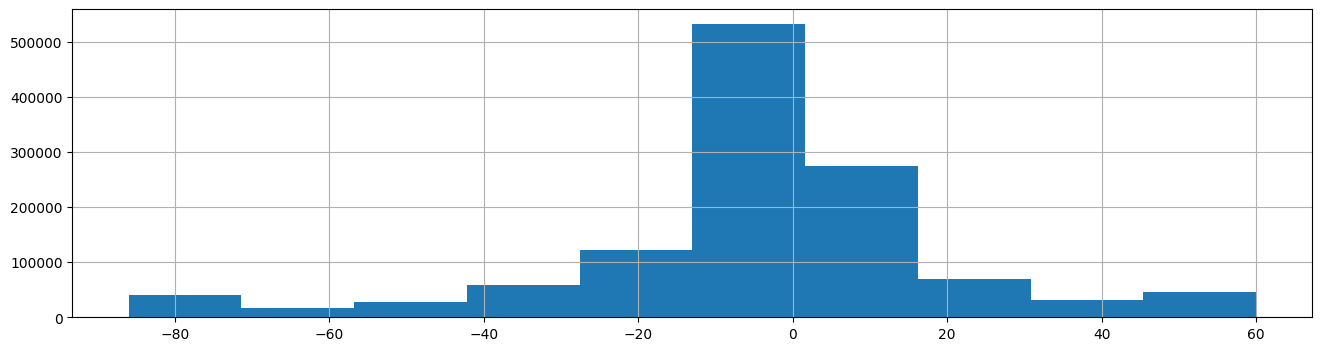

In [103]:
spread_pdf["delta_actual_forecast_days"].clip(spread_pdf["delta_actual_forecast_days"].quantile(0.025), spread_pdf["delta_actual_forecast_days"].quantile(0.975)).hist(figsize=(16, 4))

In [104]:
from matplotlib import pyplot as plt

In [105]:
filter_weeks = spread_pdf["delta_actual_forecast_weeks"] < 0

spread_pdf[filter_weeks].head()

,_id,_observ_end_dt,current_mileage,oil_mileage_per_day,oil_avg_mileage_per_day,oil_last_mileage_per_day,actual_days_until_due,forecast_days_until_due,old_forecast_days_until_due,delta_actual_forecast_days,mse_days,rmse_days,delta_actual_old_forecast_days,mse_old_forecast_days,rmse_old_forecast_days,actual_weeks_until_due,forecast_weeks_until_due,old_forecast_weeks_until_due,delta_actual_forecast_weeks,mse_weeks,rmse_weeks,delta_actual_old_forecast_weeks,mse_old_forecast_weeks,rmse_old_forecast_weeks,actual_months_until_due,forecast_months_until_due,old_forecast_months_until_due,delta_actual_forecast_months,mse_months,rmse_months,delta_actual_old_forecast_months,mse_old_forecast_months,rmse_old_forecast_months
0,0002HND__966557259037,2024-04-30,283572.0,49.293532,49.293532,68.000000,101.0,189.0,189.0,88.0,1648.600000,40.602956,88.0,4874.400000,69.816903,14.0,27.0,27.0,-13.0,36.000000,6.000000,-13.0,100.800000,10.039920,3.0,6.0,6.0,-3.0,2.200000,1.483240,-3.0,5.400000,2.323790
9,0006RSG__966530400641,2024-04-30,488517.0,31.105590,31.105590,68.000000,160.0,161.0,73.0,1.0,1.000000,1.000000,-87.0,7569.000000,87.000000,22.0,23.0,10.0,-1.0,1.000000,1.000000,12.0,144.000000,12.000000,5.0,5.0,2.0,0.0,0.000000,0.000000,3.0,9.000000,3.000000
16,0016VBD__966501222843,2024-05-31,190660.0,112.195652,68.553063,63.323077,44.0,92.0,78.0,48.0,410.727273,20.266407,34.0,314.272727,17.727739,6.0,13.0,11.0,-7.0,8.636364,2.938769,-5.0,6.909091,2.628515,1.0,3.0,2.0,-2.0,0.909091,0.953463,-1.0,0.454545,0.674200
31,0059AZZ__966550655634,2024-03-31,356718.0,64.433962,52.734423,39.523404,77.0,106.0,126.0,29.0,665.666667,25.800517,49.0,1306.000000,36.138622,11.0,15.0,18.0,-4.0,13.666667,3.696846,-7.0,27.666667,5.259911,2.0,3.0,4.0,-1.0,0.666667,0.816497,-2.0,2.000000,1.414214
56,0140BSN__966502432548,2024-10-31,422152.0,42.300578,36.189676,30.078775,118.0,166.0,166.0,48.0,577.000000,24.020824,48.0,40779.500000,201.939347,16.0,23.0,23.0,-7.0,12.500000,3.535534,-7.0,841.000000,29.000000,3.0,5.0,5.0,-2.0,1.000000,1.000000,-2.0,46.500000,6.819091


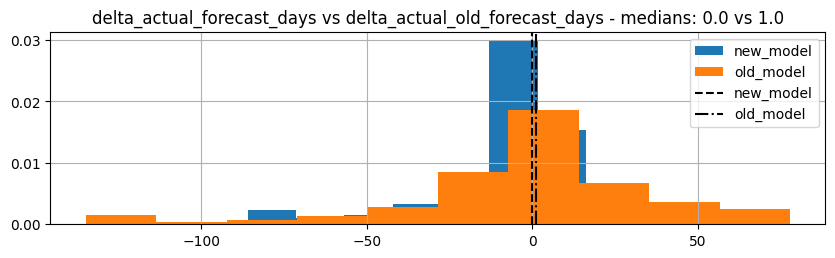

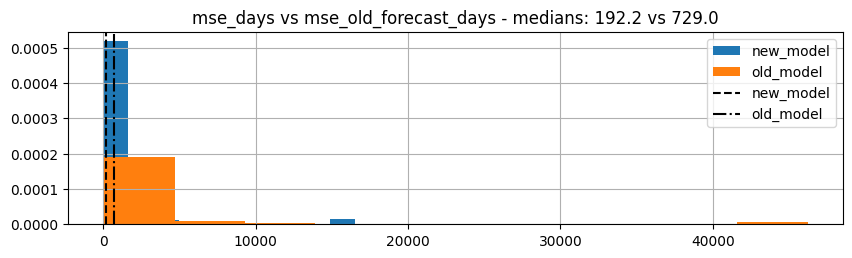

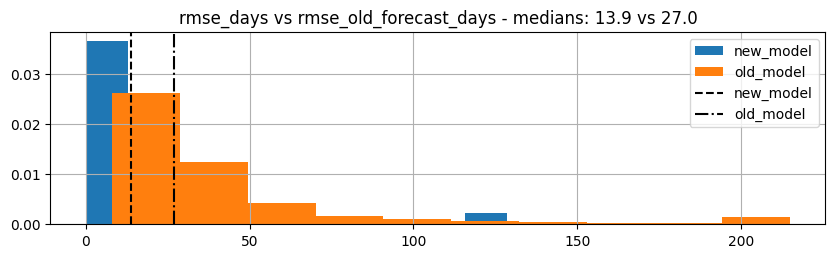

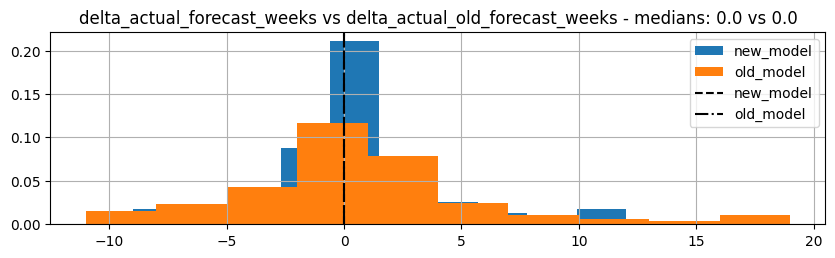

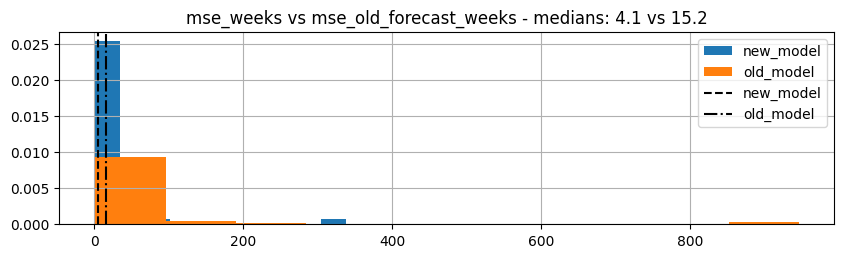

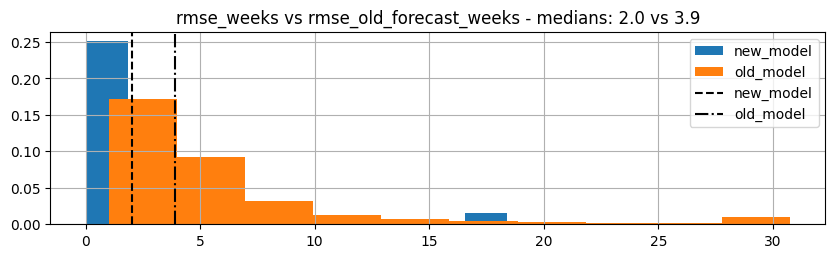

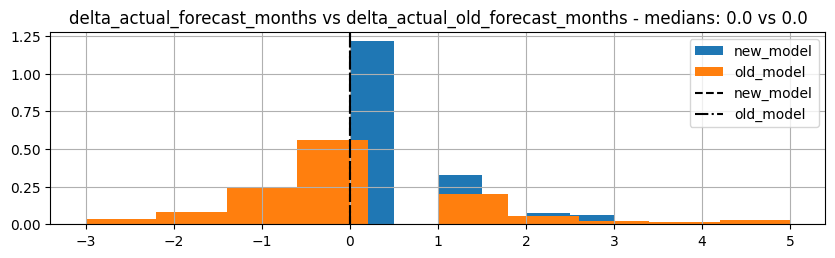

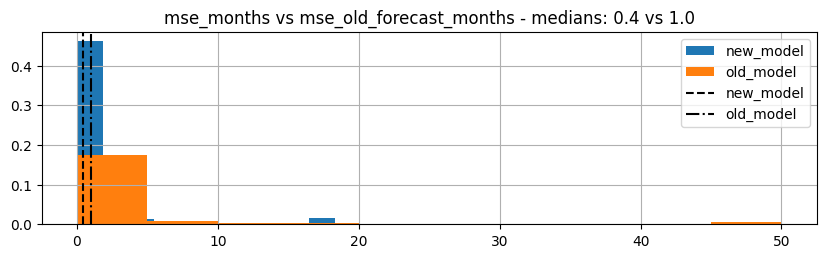

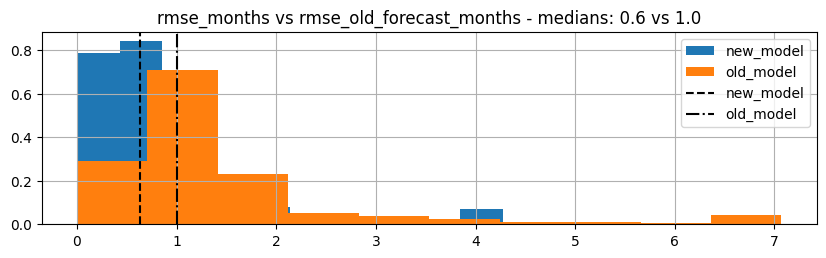

In [118]:
col_pairs_list = [
    ["delta_actual_forecast_days", "delta_actual_old_forecast_days"],
    ["mse_days", "mse_old_forecast_days"],
    ["rmse_days", "rmse_old_forecast_days"],
    ["delta_actual_forecast_weeks", "delta_actual_old_forecast_weeks"],
    ["mse_weeks", "mse_old_forecast_weeks"],
    ["rmse_weeks", "rmse_old_forecast_weeks"],
    ["delta_actual_forecast_months", "delta_actual_old_forecast_months"],
    ["mse_months", "mse_old_forecast_months"],
    ["rmse_months", "rmse_old_forecast_months"],
]

for pair in col_pairs_list:
    col_0 = pair[0]
    col_1 = pair[1]
    ax = spread_pdf[col_0].clip(spread_pdf[col_0].quantile(0.025), spread_pdf[col_0].quantile(0.975)).hist(figsize=(10, 2.5), label="new_model", density=True)
    ax = spread_pdf[col_1].clip(spread_pdf[col_1].quantile(0.025), spread_pdf[col_1].quantile(0.975)).hist(figsize=(10, 2.5), ax=ax, label="old_model", density=True)
    col_0_median = spread_pdf[col_0].clip(spread_pdf[col_0].quantile(0.025), spread_pdf[col_0].quantile(0.975)).median()
    col_1_median = spread_pdf[col_1].clip(spread_pdf[col_1].quantile(0.025), spread_pdf[col_1].quantile(0.975)).median()
    ax.axvline(col_0_median, label="new_model", color="black", linestyle="--")
    ax.axvline(col_1_median, label="old_model", color="black", linestyle="-.")
    ax.legend()
    ax.set_title(f"{col_0} vs {col_1} - medians: {col_0_median:.1f} vs {col_1_median:.1f}")
    plt.show()

In [109]:
col_pairs_list = [
    ["delta_actual_forecast_days", "delta_actual_old_forecast_days"],
    ["mse_days", "mse_old_forecast_days"],
    ["rmse_days", "rmse_old_forecast_days"],
    ["delta_actual_forecast_weeks", "delta_actual_old_forecast_weeks"],
    ["mse_weeks", "mse_old_forecast_weeks"],
    ["rmse_weeks", "rmse_old_forecast_weeks"],
    ["delta_actual_forecast_months", "delta_actual_old_forecast_months"],
    ["mse_months", "mse_old_forecast_months"],
    ["rmse_months", "rmse_old_forecast_months"],
]

metrics_list = [item for sublist in col_pairs_list for item in sublist]


clipped_spread_pdf = spread_pdf.copy()

for col in metrics_list:
    clipped_spread_pdf[col] = clipped_spread_pdf[col].clip(clipped_spread_pdf[col].quantile(0.025), clipped_spread_pdf[col].quantile(0.975))


In [111]:
metrics_quantile_df = clipped_spread_pdf[metrics_list].quantile([0, 0.025, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.975, 1])
metrics_quantile_df.index.name = "quantiles"
metrics_quantile_df

,delta_actual_forecast_days,delta_actual_old_forecast_days,mse_days,mse_old_forecast_days,rmse_days,rmse_old_forecast_days,delta_actual_forecast_weeks,delta_actual_old_forecast_weeks,mse_weeks,mse_old_forecast_weeks,rmse_weeks,rmse_old_forecast_weeks,delta_actual_forecast_months,delta_actual_old_forecast_months,mse_months,mse_old_forecast_months,rmse_months,rmse_old_forecast_months
quantiles,,,,,,,,,,,,,,,,,,
0.000,-86.0,-135.0,0.000000,65.750000,0.000000,8.108637,-9.0,-11.0,0.000000,1.000000,0.000000,1.000000,-2.0,-3.0,0.000000,0.000000,0.000000,0.000000
0.025,-86.0,-135.0,0.000000,65.750000,0.000000,8.108637,-9.0,-11.0,0.000000,1.000000,0.000000,1.000000,-2.0,-3.0,0.000000,0.000000,0.000000,0.000000
0.050,-55.0,-79.0,0.000000,121.000000,0.000000,11.000000,-5.0,-8.0,0.000000,2.500000,0.000000,1.581139,-1.0,-2.0,0.000000,0.142857,0.000000,0.377964
0.100,-32.0,-43.0,0.333333,186.000000,0.577350,13.638182,-3.0,-6.0,0.000000,4.000000,0.000000,2.000000,-1.0,-1.0,0.000000,0.285714,0.000000,0.534522
0.250,-11.0,-14.0,40.500000,344.500000,6.363961,18.560711,-1.0,-2.0,1.000000,7.200000,1.000000,2.683282,0.0,-1.0,0.000000,0.500000,0.000000,0.707107
0.500,0.0,1.0,192.200000,729.000000,13.863621,27.000000,0.0,0.0,4.133333,15.200000,2.033060,3.898718,0.0,0.0,0.394737,1.000000,0.628281,1.000000
0.750,6.0,17.0,723.000000,1880.666667,26.888659,43.366654,2.0,2.0,15.000000,37.666667,3.872983,6.137318,0.0,1.0,1.000000,2.333333,1.000000,1.527525
0.900,20.0,42.0,2592.000000,5933.704762,50.911688,77.030544,5.0,6.0,52.833333,121.000000,7.268654,11.000000,1.0,1.0,3.000000,6.714286,1.732051,2.591194
0.950,36.0,58.0,6368.378750,16358.500000,79.802122,127.900352,8.0,11.0,129.700000,332.114667,11.388591,18.224013,2.0,3.0,7.363636,17.833333,2.713602,4.222953


In [112]:
metrics_quantile_df[[metric for metric in metrics_list if "rmse" in metric]]

,rmse_days,rmse_old_forecast_days,rmse_weeks,rmse_old_forecast_weeks,rmse_months,rmse_old_forecast_months
quantiles,,,,,,
0.000,0.000000,8.108637,0.000000,1.000000,0.000000,0.000000
0.025,0.000000,8.108637,0.000000,1.000000,0.000000,0.000000
0.050,0.000000,11.000000,0.000000,1.581139,0.000000,0.377964
0.100,0.577350,13.638182,0.000000,2.000000,0.000000,0.534522
0.250,6.363961,18.560711,1.000000,2.683282,0.000000,0.707107
0.500,13.863621,27.000000,2.033060,3.898718,0.628281,1.000000
0.750,26.888659,43.366654,3.872983,6.137318,1.000000,1.527525
0.900,50.911688,77.030544,7.268654,11.000000,1.732051,2.591194
0.950,79.802122,127.900352,11.388591,18.224013,2.713602,4.222953


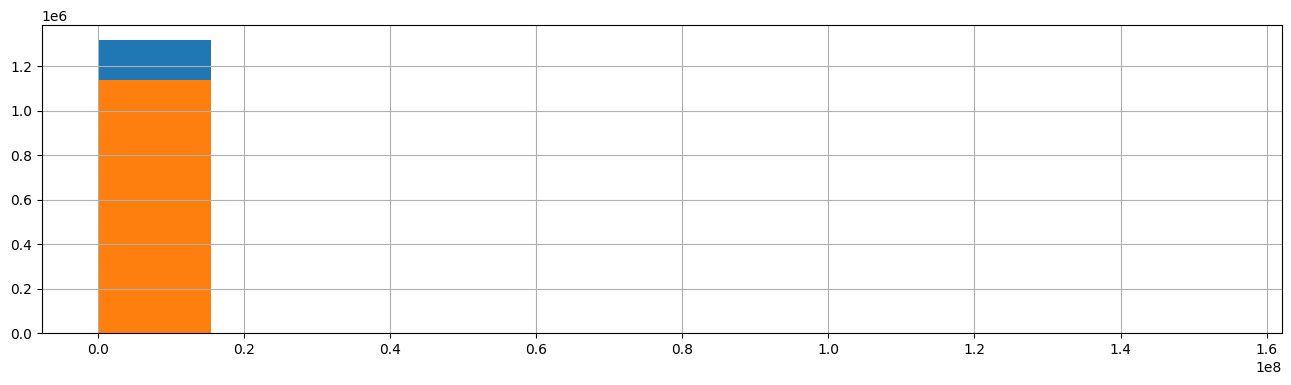

In [50]:
ax = spread_pdf[["rmse_months", "rmse_old_forecast_months"][0]].hist(figsize=(16, 4))
ax = spread_pdf[["rmse_months", "rmse_old_forecast_months"][1]].hist(figsize=(16, 4), ax=ax)

In [ ]:
# spread_pdf = spread_df.filter(
#     f.year("_observ_end_dt") == 2024
# ).filter(
#     f.col("current_mileage").isNotNull()
# ).select(
#     "_id",
#     "_observ_end_dt",
#     "current_mileage",
#     "oil_mileage_per_day",
#     "oil_avg_mileage_per_day",
#     "oil_last_mileage_per_day",
#     "actual_months_until_due",
#     "forecast_months_until_due",
#     "old_forecast_months_until_due",
#     "delta_actual_forecast_months",
#     "mse_months",
#     "rmse_months",
#     "delta_actual_old_forecast_months",
#     "mse_old_forecast_months",
#     "rmse_old_forecast_months",
# ).pandas_api()

In [38]:
spread_pdf.head()

25/05/25 01:38:21 ERROR BaseAllocator: Memory was leaked by query. Memory leaked: (507904)
Allocator(toArrowBatchIterator) 0/507904/507904/9223372036854775807 (res/actual/peak/limit)

25/05/25 01:38:21 ERROR TaskContextImpl: Error in TaskCompletionListener
java.lang.IllegalStateException: Memory was leaked by query. Memory leaked: (507904)
Allocator(toArrowBatchIterator) 0/507904/507904/9223372036854775807 (res/actual/peak/limit)

	at org.apache.arrow.memory.BaseAllocator.close(BaseAllocator.java:476)
	at org.apache.spark.sql.execution.arrow.ArrowConverters$ArrowBatchIterator.close(ArrowConverters.scala:128)
	at org.apache.spark.sql.execution.arrow.ArrowConverters$ArrowBatchIterator.$anonfun$new$2(ArrowConverters.scala:96)
	at org.apache.spark.sql.execution.arrow.ArrowConverters$ArrowBatchIterator.$anonfun$new$2$adapted(ArrowConverters.scala:95)
	at org.apache.spark.TaskContext$$anon$1.onTaskCompletion(TaskContext.scala:137)
	at org.apache.spark.TaskContextImpl.$anonfun$invokeTaskCompl

Py4JJavaError: An error occurred while calling o2054.getResult.
: org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.security.SocketAuthServer.getResult(SocketAuthServer.scala:98)
	at org.apache.spark.security.SocketAuthServer.getResult(SocketAuthServer.scala:94)
	at java.base/jdk.internal.reflect.DirectMethodHandleAccessor.invoke(DirectMethodHandleAccessor.java:103)
	at java.base/java.lang.reflect.Method.invoke(Method.java:580)
	at py4j.reflection.MethodInvoker.invoke(MethodInvoker.java:244)
	at py4j.reflection.ReflectionEngine.invoke(ReflectionEngine.java:374)
	at py4j.Gateway.invoke(Gateway.java:282)
	at py4j.commands.AbstractCommand.invokeMethod(AbstractCommand.java:132)
	at py4j.commands.CallCommand.execute(CallCommand.java:79)
	at py4j.ClientServerConnection.waitForCommands(ClientServerCon

25/05/25 01:43:56 ERROR BaseAllocator: Memory was leaked by query. Memory leaked: (507904)
Allocator(toArrowBatchIterator) 0/507904/507904/9223372036854775807 (res/actual/peak/limit)

25/05/25 01:43:56 ERROR TaskContextImpl: Error in TaskCompletionListener
java.lang.IllegalStateException: Memory was leaked by query. Memory leaked: (507904)
Allocator(toArrowBatchIterator) 0/507904/507904/9223372036854775807 (res/actual/peak/limit)

	at org.apache.arrow.memory.BaseAllocator.close(BaseAllocator.java:476)
	at org.apache.spark.sql.execution.arrow.ArrowConverters$ArrowBatchIterator.close(ArrowConverters.scala:128)
	at org.apache.spark.sql.execution.arrow.ArrowConverters$ArrowBatchIterator.$anonfun$new$2(ArrowConverters.scala:96)
	at org.apache.spark.sql.execution.arrow.ArrowConverters$ArrowBatchIterator.$anonfun$new$2$adapted(ArrowConverters.scala:95)
	at org.apache.spark.TaskContext$$anon$1.onTaskCompletion(TaskContext.scala:137)
	at org.apache.spark.TaskContextImpl.$anonfun$invokeTaskCompl

Py4JJavaError: An error occurred while calling o2100.getResult.
: org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.security.SocketAuthServer.getResult(SocketAuthServer.scala:98)
	at org.apache.spark.security.SocketAuthServer.getResult(SocketAuthServer.scala:94)
	at java.base/jdk.internal.reflect.DirectMethodHandleAccessor.invoke(DirectMethodHandleAccessor.java:103)
	at java.base/java.lang.reflect.Method.invoke(Method.java:580)
	at py4j.reflection.MethodInvoker.invoke(MethodInvoker.java:244)
	at py4j.reflection.ReflectionEngine.invoke(ReflectionEngine.java:374)
	at py4j.Gateway.invoke(Gateway.java:282)
	at py4j.commands.AbstractCommand.invokeMethod(AbstractCommand.java:132)
	at py4j.commands.CallCommand.execute(CallCommand.java:79)
	at py4j.ClientServerConnection.waitForCommands(ClientServerCon

In [33]:
spread_df.filter(
    f.col("current_mileage").isNotNull()
).groupBy("_id").agg(
    f.countDistinct("_observ_end_dt").alias("count")
).filter(
    f.col("count") > 10
).show(truncate=False)

+---------------------+-----+
|_id                  |count|
+---------------------+-----+
|0016VBD__966501222843|14   |
|0956EBN__966557862834|16   |
|1033LNB__966501030453|19   |
|1036LEJ__966568889070|22   |
|1065XJJ__966569554791|19   |
|1098GBB__966555079565|13   |
|1118NTA__966506100298|21   |
|1146HVA__966510746604|17   |
|1205VKD__966552984182|19   |
|1236DJJ__966542062975|18   |
|1255RRD__966582390577|21   |
|1257HNJ__966557603398|19   |
|1312SGJ__966553844473|13   |
|1330GND__966590002228|11   |
|1367GSJ__966544863646|20   |
|1413ZJJ__966599268047|14   |
|1417EHD__966510986302|14   |
|1458RAR__966530262035|12   |
|1508HGD__966597475898|18   |
|1556KSD__966591539962|25   |
+---------------------+-----+
only showing top 20 rows



In [34]:
working_ids = [
    "0016VBD__966501222843",
    "1033LNB__966501030453",
    "1036LEJ__966568889070",
    "1065XJJ__966569554791",
    "1118NTA__966506100298",
    "1255RRD__966582390577",
    "1556KSD__966591539962",
]

In [58]:
spread_df.filter(
    f.col("_id") == working_ids[0]
).select(
    "_id",
    "_observ_end_dt",
    "current_mileage",
    "oil_mileage_per_day",
    "actual_days_until_due",
    "oil_avg_mileage_per_day",
    "forecast_days_until_due",
    "delta_actual_forecast",
    "mse",
    "rmse",
).show(50, truncate=False)

+---------------------+--------------+---------------+-------------------+---------------------+-----------------------+-----------------------+---------------------+------------------+------------------+
|_id                  |_observ_end_dt|current_mileage|oil_mileage_per_day|actual_days_until_due|oil_avg_mileage_per_day|forecast_days_until_due|delta_actual_forecast|mse               |rmse              |
+---------------------+--------------+---------------+-------------------+---------------------+-----------------------+-----------------------+---------------------+------------------+------------------+
|0016VBD__966501222843|2021-04-30    |122397.0       |NULL               |NULL                 |57.0                   |NULL                   |NULL                 |NULL              |NULL              |
|0016VBD__966501222843|2021-05-31    |NULL           |NULL               |NULL                 |57.0                   |87                     |NULL                 |NULL          

In [59]:
spread_df.filter(
    f.year("_observ_end_dt") == 2024
).filter(
    f.col("current_mileage").isNotNull()
).groupBy(
    "_observ_end_dt",
).agg(
    f.percentile("delta_actual_forecast", 0.05).alias("delta_actual_forecast_005"),
    f.percentile("delta_actual_forecast", 0.1).alias("delta_actual_forecast_010"),
    f.percentile("delta_actual_forecast", 0.5).alias("delta_actual_forecast_050"),
    f.percentile("delta_actual_forecast", 0.9).alias("delta_actual_forecast_090"),
    f.percentile("delta_actual_forecast", 0.95).alias("delta_actual_forecast_095"),

    f.percentile("mse", 0.05).alias("mse_005"),
    f.percentile("mse", 0.1).alias("mse_010"),
    f.percentile("mse", 0.5).alias("mse_050"),
    f.percentile("mse", 0.9).alias("mse_090"),
    f.percentile("mse", 0.95).alias("mse_095"),

    f.percentile("rmse", 0.05).alias("rmse_005"),
    f.percentile("rmse", 0.1).alias("rmse_010"),
    f.percentile("rmse", 0.25).alias("rmse_025"),
    f.percentile("rmse", 0.5).alias("rmse_050"),
    f.percentile("rmse", 0.75).alias("rmse_075"),
    f.percentile("rmse", 0.9).alias("rmse_090"),
    f.percentile("rmse", 0.95).alias("rmse_095"),
).show(20, truncate=False)

+--------------+-------------------------+-------------------------+-------------------------+-------------------------+-------------------------+-------+------------------+------------------+------------------+-----------------+--------+------------------+------------------+------------------+------------------+------------------+-----------------+
|_observ_end_dt|delta_actual_forecast_005|delta_actual_forecast_010|delta_actual_forecast_050|delta_actual_forecast_090|delta_actual_forecast_095|mse_005|mse_010           |mse_050           |mse_090           |mse_095          |rmse_005|rmse_010          |rmse_025          |rmse_050          |rmse_075          |rmse_090          |rmse_095         |
+--------------+-------------------------+-------------------------+-------------------------+-------------------------+-------------------------+-------+------------------+------------------+------------------+-----------------+--------+------------------+------------------+------------------+-

In [57]:
spread_df.filter(
    f.year("_observ_end_dt") == 2024
).filter(
    f.col("current_mileage").isNotNull()
).groupBy(
    "_observ_end_dt",
).agg(
    f.percentile("delta_actual_forecast", 0.05).alias("delta_actual_forecast_005"),
    f.percentile("delta_actual_forecast", 0.1).alias("delta_actual_forecast_010"),
    f.percentile("delta_actual_forecast", 0.5).alias("delta_actual_forecast_050"),
    f.percentile("delta_actual_forecast", 0.9).alias("delta_actual_forecast_090"),
    f.percentile("delta_actual_forecast", 0.95).alias("delta_actual_forecast_095"),

    f.percentile("mse", 0.05).alias("mse_005"),
    f.percentile("mse", 0.1).alias("mse_010"),
    f.percentile("mse", 0.5).alias("mse_050"),
    f.percentile("mse", 0.9).alias("mse_090"),
    f.percentile("mse", 0.95).alias("mse_095"),

    f.percentile("rmse", 0.05).alias("rmse_005"),
    f.percentile("rmse", 0.1).alias("rmse_010"),
    f.percentile("rmse", 0.25).alias("rmse_025"),
    f.percentile("rmse", 0.5).alias("rmse_050"),
    f.percentile("rmse", 0.75).alias("rmse_075"),
    f.percentile("rmse", 0.9).alias("rmse_090"),
    f.percentile("rmse", 0.95).alias("rmse_095"),
).select(
    f.mean("delta_actual_forecast_005").alias("delta_actual_forecast_005"),
    f.mean("delta_actual_forecast_010").alias("delta_actual_forecast_010"),
    f.mean("delta_actual_forecast_050").alias("delta_actual_forecast_050"),
    f.mean("delta_actual_forecast_090").alias("delta_actual_forecast_090"),
    f.mean("delta_actual_forecast_095").alias("delta_actual_forecast_095"),

    f.mean("mse_005").alias("mse_005"),
    f.mean("mse_010").alias("mse_010"),
    f.mean("mse_050").alias("mse_050"),
    f.mean("mse_090").alias("mse_090"),
    f.mean("mse_095").alias("mse_095"),

    f.mean("rmse_005").alias("rmse_005"),
    f.mean("rmse_010").alias("rmse_010"),
    f.mean("rmse_025").alias("rmse_025"),
    f.mean("rmse_050").alias("rmse_050"),
    f.mean("rmse_075").alias("rmse_075"),
    f.mean("rmse_090").alias("rmse_090"),
    f.mean("rmse_095").alias("rmse_095"),
).show(20, truncate=False)

+-------------------------+-------------------------+-------------------------+-------------------------+-------------------------+-------+------------------+------------------+------------------+---------------+--------+------------------+-----------------+-----------------+------------------+-----------------+-----------------+
|delta_actual_forecast_005|delta_actual_forecast_010|delta_actual_forecast_050|delta_actual_forecast_090|delta_actual_forecast_095|mse_005|mse_010           |mse_050           |mse_090           |mse_095        |rmse_005|rmse_010          |rmse_025         |rmse_050         |rmse_075          |rmse_090         |rmse_095         |
+-------------------------+-------------------------+-------------------------+-------------------------+-------------------------+-------+------------------+------------------+------------------+---------------+--------+------------------+-----------------+-----------------+------------------+-----------------+-----------------+
|-36

## Client Brand table

In [29]:
client_mileage_product_forecast.filter(
    f.col("_observ_end_dt") == "2025-05-31"
).select(
    f.sum("oil_is_due").alias("# mineral clients due"),
    f.sum(f.when(f.col("oil_is_due_branch") == "PE", 1)).alias("# mineral clients due PE"),
    f.sum(f.when(f.col("oil_is_due_branch") == "PAC", 1)).alias("# mineral clients due PAC"),
    f.sum("oil_synthetic_is_due").alias("# synthetic clients due"),
    f.sum(f.when(f.col("oil_synthetic_is_due_branch") == "PE", 1)).alias("# synthetic clients due PE"),
    f.sum(f.when(f.col("oil_synthetic_is_due_branch") == "PAC", 1)).alias("# synthetic clients due PAC"),
).show()

+---------------------+------------------------+-------------------------+-----------------------+--------------------------+---------------------------+
|# mineral clients due|# mineral clients due PE|# mineral clients due PAC|# synthetic clients due|# synthetic clients due PE|# synthetic clients due PAC|
+---------------------+------------------------+-------------------------+-----------------------+--------------------------+---------------------------+
|              1803607|                 1588692|                   214915|                1595288|                   1404667|                     190621|
+---------------------+------------------------+-------------------------+-----------------------+--------------------------+---------------------------+



In [30]:
client_mileage_product_forecast.filter(
    f.col("_observ_end_dt") == "2025-06-30"
).select(
    f.sum("oil_is_due").alias("# mineral clients due"),
    f.sum(f.when(f.col("oil_is_due_branch") == "PE", 1)).alias("# mineral clients due PE"),
    f.sum(f.when(f.col("oil_is_due_branch") == "PAC", 1)).alias("# mineral clients due PAC"),
    f.sum("oil_synthetic_is_due").alias("# synthetic clients due"),
    f.sum(f.when(f.col("oil_synthetic_is_due_branch") == "PE", 1)).alias("# synthetic clients due PE"),
    f.sum(f.when(f.col("oil_synthetic_is_due_branch") == "PAC", 1)).alias("# synthetic clients due PAC"),
).show()

+---------------------+------------------------+-------------------------+-----------------------+--------------------------+---------------------------+
|# mineral clients due|# mineral clients due PE|# mineral clients due PAC|# synthetic clients due|# synthetic clients due PE|# synthetic clients due PAC|
+---------------------+------------------------+-------------------------+-----------------------+--------------------------+---------------------------+
|              1880588|                 1657097|                   223491|                1661146|                   1463501|                     197645|
+---------------------+------------------------+-------------------------+-----------------------+--------------------------+---------------------------+



In [73]:
for date in ["2025-05-31", "2025-06-30"]:
    print("date:", date)
    for cat in major_categories_list:
        print("cat:", cat)
        client_mileage_product_forecast.withColumn(
            "customer_oil",
            f.when(
                f.col("oil_last_transaction_dt").isNull(),
                f.lit("Synthetic")
            ).when(
                f.col("oil_synthetic_last_transaction_dt").isNull(),
                f.lit("Mineral")
            ).when(
                f.col("oil_synthetic_last_transaction_dt") > f.col("oil_last_transaction_dt"),
                f.lit("Synthetic")
            ).otherwise("Mineral")
        # ).withColumn(
        #     "last_transaction_dt",
        #     f.when(
        #         f.col("customer_oil") == "Mineral",
        #         f.col("oil_last_transaction_dt")
        #     ).when(
        #         f.col("customer_oil") == "Synthetic",
        #         f.col("oil_synthetic_last_transaction_dt")
        #     ).otherwise(None)
        # ).withColumn(
        #     "avg_mileage_per_day",
        #     f.when(
        #         f.col("customer_oil") == "Mineral",
        #         f.col("oil_avg_mileage_per_day")
        #     ).when(
        #         f.col("customer_oil") == "Synthetic",
        #         f.col("oil_synthetic_avg_mileage_per_day")
        #     ).otherwise(None)
        # ).withColumn(
        #     "mileage_when_due",
        #     f.when(
        #         f.col("customer_oil") == "Mineral",
        #         f.col("oil_mileage_when_due")
        #     ).when(
        #         f.col("customer_oil") == "Synthetic",
        #         f.col("oil_synthetic_mileage_when_due")
        #     ).otherwise(None)
        # ).withColumn(
        #     "is_due_branch",
        #     f.when(
        #         f.col("customer_oil") == "Mineral",
        #         f.col("oil_is_due_branch")
        #     ).when(
        #         f.col("customer_oil") == "Synthetic",
        #         f.col("oil_synthetic_is_due_branch")
        #     ).otherwise(None)
        ).filter(
            f.col("_observ_end_dt") == date
        ).filter(
            f.col(f"{cat}_is_due") > 0
        ).select(
            "_id",
            "_observ_end_dt",
            "last_mileage",
            "customer_oil",
            f"{cat}_last_transaction_dt",
            f"{cat}_avg_mileage_per_day",
            f"{cat}_mileage_when_due",
            f"{cat}_is_due_branch",
        ).write.mode("overwrite").parquet(f"data_output/mileage_model_{cat}_{date.replace("-","")}.parquet")

date: 2025-05-31
cat: oil


cat: oil_synthetic


date: 2025-06-30
cat: oil


cat: oil_synthetic


In [53]:
client_mileage_product_forecast.filter(
    f.col("_id") == "00000E2B-FD56-4F34-A54C-159E564F5F79__FF8A2477-4270-4547-B4CB-5706EA4479A0"
).withColumn(
    "customer_oil",
    f.when(
        f.col("oil_synthetic_last_transaction_dt") > f.col("oil_last_transaction_dt"),
        f.lit("Synthetic")
    ).otherwise(f.lit("Mineral"))
).orderBy("_id", "_observ_end_dt").show(50, truncate=False)

+--------------------------------------------------------------------------+--------------+---------------+------------+-----------------------+---------------------------------+-----------------------+---------------------------------+-----------------------+---------------------+----------+--------------------+--------------+--------------+-----------------+---------------------------------+-------------------------------+--------------------+------------------------------+------------------------+------------------------+---------------------------+------------+
|_id                                                                       |_observ_end_dt|current_mileage|last_mileage|oil_avg_mileage_per_day|oil_synthetic_avg_mileage_per_day|oil_last_transaction_dt|oil_synthetic_last_transaction_dt|oil_days_since_last_trx|oil_days_until_change|oil_is_due|oil_mileage_when_due|oil_is_due_40k|oil_is_due_80k|oil_is_due_branch|oil_synthetic_days_since_last_trx|oil_synthetic_days_until_change|

# Loyal Segments

In [ ]:
win_id_transaction = Window.partitionBy("_id").orderBy("transaction_dt")

base_sales = base_sales.withColumn(
    "first_visit_dt",
    f.first("transaction_dt", ignorenulls=True).over(win_id_transaction).over(Window.unboundedPreceding, 0)
).withColumn(
    "last_visit_dt",
    f.last("transaction_dt", ignorenulls=True).over(win_id_transaction).over(Window.unboundedPreceding, 0)
).withColumn(
    "months_since_first_visit",
    f.floor(f.months_between(f.col("_observ_end_dt"), f.col("first_visit_dt")))
).withColumn(
    "months_since_last_visit",
    f.floor(f.months_between(f.col("_observ_end_dt"), f.col("last_visit_dt")))
).withColumn(
    "total_number_of_visits",
    f.countDistinct("transaction_id").over(win_id_transaction).over(Window.unboundedPreceding, 0)
).withColumn(
    "total_number_of_visits_last_12_months",
    f.countDistinct("transaction_id").over(win_id_transaction).over(-11, 0)
).withColumn(
    "expected_number_of_visits_mineral_oil",
    f.floor((f.col("currently_avg_mileage_per_day") * f.lit(365)) / 5000)
).withColumn(
    "expected_number_of_visits_synthetical_oil",
    f.floor((f.col("currently_avg_mileage_per_day") * f.lit(365)) / 10000)
).withColumn(
    "is_new_joiner",
    f.when(
        (f.col("total_number_of_visits") == 1) &
        (f.col("months_since_last_visit") <= 12) &
        (f.col("months_since_last_visit") <= 12),
        1
    ).otherwise(0)
).withColumn(
    "is_uncommited",
    f.when(
        (f.col("total_number_of_visits_last_12_months") == 1) &
        (f.col("months_since_last_visit") <= 24),
        1
    ).otherwise(0)
).withColumn(
    "is_loyal",
    f.when(
        (f.col("total_number_of_visits_last_12_months") >= 3) &
        (((f.col("customer_mineral_oil") > 0) & (f.col("total_number_of_visits_last_12_months") >= f.col("expected_number_of_visits_mineral_oil"))) |
        ((f.col("customer_synthetical_oil") > 0) & (f.col("total_number_of_visits_last_12_months") >= f.col("expected_number_of_visits_synthetical_oil"))))
        1
    ).otherwise(0)
).withColumn(
    "is_potential_loyal",
    f.when(
        (f.col("total_number_of_visits_last_12_months") >= 2) &
        (((f.col("customer_mineral_oil") > 0) & (f.col("total_number_of_visits_last_12_months") < f.col("expected_number_of_visits_mineral_oil"))) |
        ((f.col("customer_synthetical_oil") > 0) & (f.col("total_number_of_visits_last_12_months") < f.col("expected_number_of_visits_synthetical_oil"))))
        1
    ).otherwise(0)
).withColumn(
    "is_lost",
    f.when(
        (f.col("months_since_last_visit") > 12) &
        (f.col("months_since_last_visit") <= 24),
        1
    ).otherwise(0)
).withColumn(
    "is_lost",
    f.when(
        (f.col("months_since_last_visit") > 24),
        1
    ).otherwise(0)
)

## Read customer/vehicle information

In [74]:
import pandas as pd
import numpy as np

In [75]:
int_vehicle = pd.read_parquet("../data/02_intermediate/int_vehicles")
int_customer = pd.read_parquet("../data/02_intermediate/int_customers")

In [135]:
date = "2025-06-30"

In [136]:
mileage_prediction_mineral = pd.read_parquet(f"data_output/mileage_model_oil_{date.replace("-","")}.parquet")
mileage_prediction_synthetic = pd.read_parquet(f"data_output/mileage_model_oil_synthetic_{date.replace("-","")}.parquet")

In [137]:
int_vehicle.head(2)

,customer_vehicle_id,creation_on,modified_on,customer_id,maker,model,model_year,transmission_type,pms_name,plate_number,code_vin,is_driver_owner,station_brand,is_truck,vehicle_brand_level,_id
0,918FE112-E062-4A56-8033-000001BFCEC6,2021-03-12,2020-03-26,40AA5E88-1966-4494-B3FE-54112BF3F479,CHEVROLET,SUBURBAN,2013.0,AUTOMATIC,None,5340AAJ,1GNSC8E07DR219313,False,PE,0,LOW,40AA5E88-1966-4494-B3FE-54112BF3F479__918FE112...
1,1B4AA1DD-1E18-4990-AB45-000002BF3307,2021-03-12,2020-03-26,E1EAFA23-0ADC-4AFA-A774-4E27CDA23AA9,LEXUS,LS400,1998.0,AUTOMATIC,TOYOTA,0068LAZ,JTB530F20W0115484,False,PE,0,HIGH,E1EAFA23-0ADC-4AFA-A774-4E27CDA23AA9__1B4AA1DD...


In [138]:
int_customer.head(2)

,customer_id,creation_on,modified_on,user_title,customer_name,mobile,mobile2,email,gender,nationality,birth_date,location_name,is_owner,is_cash_customer,payterm,age,is_active,station_brand
0,EB5670AA-72D8-49CE-8FAC-00000859EB85,2021-03-12,2020-03-26,None,ABU RAKAN,0555551397,None,None,None,None,1900-01-01,None,True,True,None,NaN,True,PE
1,4C86E939-005E-4611-B4C1-00000A03F8CA,2021-03-12,2020-03-26,None,MR OLAYYAN,0547502121,None,None,None,None,1900-01-01,None,True,True,None,NaN,True,PE


In [139]:
mileage_prediction_mineral.head(2)

,_id,_observ_end_dt,last_mileage,customer_oil,oil_last_transaction_dt,oil_avg_mileage_per_day,oil_mileage_when_due,oil_is_due_branch
0,00000540-7986-4B85-A946-E1A9D913344F__F40BF538...,2025-06-30,90014.0,Mineral,2023-04-11 16:07:36,68.0,145162.0,PE
1,00000847-CECD-43FB-A2F9-4D4B44A8BFFC__FF645321...,2025-06-30,219209.0,Mineral,2022-07-29 17:54:54,115.0,341914.0,PE


In [140]:
mileage_prediction_synthetic.head(2)

,_id,_observ_end_dt,last_mileage,customer_oil,oil_synthetic_last_transaction_dt,oil_synthetic_avg_mileage_per_day,oil_synthetic_mileage_when_due,oil_synthetic_is_due_branch
0,00000540-7986-4B85-A946-E1A9D913344F__F40BF538...,2025-06-30,90014.0,Mineral,NaT,68.0,145162.0,PE
1,00000847-CECD-43FB-A2F9-4D4B44A8BFFC__FF645321...,2025-06-30,219209.0,Mineral,NaT,68.0,291765.0,PE


In [141]:
mileage_prediction_synthetic = mileage_prediction_synthetic[~mileage_prediction_synthetic["oil_synthetic_last_transaction_dt"].isnull()]
mileage_prediction_synthetic.shape

(248608, 8)

In [142]:
mileage_prediction_mineral = mileage_prediction_mineral[~mileage_prediction_mineral["oil_is_due_branch"].isnull()]
mileage_prediction_mineral.shape

(1880588, 8)

In [143]:
mileage_prediction_synthetic = mileage_prediction_synthetic[mileage_prediction_synthetic["oil_synthetic_last_transaction_dt"] >= "2024-01-01"]
mileage_prediction_mineral = mileage_prediction_mineral[mileage_prediction_mineral["oil_last_transaction_dt"] >= "2024-01-01"]

In [144]:
int_vehicle["_id"] = int_vehicle["customer_id"] + "__" + int_vehicle["customer_vehicle_id"]

In [145]:
vehicles_cols = ["_id", "customer_id", "customer_vehicle_id", "maker", "model", "model_year", "plate_number", "is_truck"]
customer_cols = ["customer_id", "mobile", "gender", "nationality"]

In [146]:
customer_vehicle_df = pd.merge(
    int_vehicle[vehicles_cols],
    int_customer[customer_cols],
    on="customer_id",
    how="inner"
)

In [147]:
customer_vehicle_df["plate_number"] = customer_vehicle_df["plate_number"].str.zfill(7)
customer_vehicle_df["mobile"] = customer_vehicle_df["mobile"].astype("string")
customer_vehicle_df["mobile"] = customer_vehicle_df["mobile"].str.zfill(10)
customer_vehicle_df["mobile"] = customer_vehicle_df["mobile"].str.slice_replace(stop=1, repl='966')

In [148]:
print(int_vehicle.shape)
print(int_customer.shape)
print(customer_vehicle_df.shape)
print(mileage_prediction_mineral.shape)
print(mileage_prediction_synthetic.shape)

(7074963, 16)
(7070056, 18)
(7074963, 11)
(736284, 8)
(84858, 8)


In [149]:
customer_vehicle_df_mineral = pd.merge(
    customer_vehicle_df,
    mileage_prediction_mineral,
    on="_id",
    how="inner"
)

print(customer_vehicle_df_mineral.shape)

(736284, 18)


In [150]:
customer_vehicle_df_synthetic = pd.merge(
    customer_vehicle_df,
    mileage_prediction_synthetic,
    on="_id",
    how="inner"
)

print(customer_vehicle_df_synthetic.shape)

(84858, 18)


## Brand Pivot Table

In [151]:
last_year_customer_vehicle_df = customer_vehicle_df_mineral[customer_vehicle_df_mineral["oil_last_transaction_dt"] >= "2024-01-01"].copy()

In [152]:
last_year_customer_vehicle_df.to_excel(f"data_output/mileage_model_mineral_{date.replace("-","")}.xlsx", engine="openpyxl", index=False)

In [153]:
branch_table = last_year_customer_vehicle_df.groupby(["oil_is_due_branch", "customer_oil"]).agg({"_id": "count"})
branch_table.unstack("oil_is_due_branch")

_id        
oil_is_due_branch    PAC      PE
customer_oil                    
Mineral            84750  626347
Synthetic           3051   22136

In [154]:
brand_table = last_year_customer_vehicle_df[last_year_customer_vehicle_df["maker"].isin(
    ['TOYOTA', 'HYUNDAI', 'NISSAN', 'KIA', 'ISUZU', 'FORD', 'CHEVROLET', 'HONDA', 'MITSUBISHI', 'GMC', 'LEXUS', 'MAZDA', 'SUZUKI', 'CHANGAN', 'RENAULT']
)].groupby(["oil_is_due_branch", "maker", "customer_oil"]).agg({"_id": "count"})
brand_table.unstack("oil_is_due_branch").unstack("customer_oil")

_id                            
oil_is_due_branch     PAC                PE          
customer_oil      Mineral Synthetic Mineral Synthetic
maker                                                
CHANGAN               485        43    3541       292
CHEVROLET            2435       122   17576       880
FORD                 3141       169   23363      1178
GMC                  1460        51   10896       377
HONDA                2293        59   17026       552
HYUNDAI             18129       644  133299      4576
ISUZU                3525         8   26706        30
KIA                  5991       248   44027      1975
LEXUS                1461        70   10319       535
MAZDA                1342       107    9785       655
MITSUBISHI           2236        55   16495       419
NISSAN               6484       277   47530      2009
RENAULT               523        38    3708       247
SUZUKI                585        51    4364       315
TOYOTA              30976       902  230623      6501

### Synthetic

In [155]:
date = "2025-06-30"

In [156]:
date

'2025-06-30'

In [157]:
last_year_customer_vehicle_df = customer_vehicle_df_synthetic[customer_vehicle_df_synthetic["oil_synthetic_last_transaction_dt"] >= "2024-01-01"].copy()

In [158]:
last_year_customer_vehicle_df.to_excel(f"data_output/mileage_model_synthetic_{date.replace("-","")}.xlsx", engine="openpyxl", index=False)

In [159]:
branch_table = last_year_customer_vehicle_df.groupby(["oil_synthetic_is_due_branch", "customer_oil"]).agg({"_id": "count"})
branch_table.unstack("oil_synthetic_is_due_branch")

_id       
oil_synthetic_is_due_branch   PAC     PE
customer_oil                            
Mineral                      1613  11094
Synthetic                    8536  63615

In [160]:
brand_table = last_year_customer_vehicle_df[last_year_customer_vehicle_df["maker"].isin(
    ['TOYOTA', 'HYUNDAI', 'NISSAN', 'KIA', 'ISUZU', 'FORD', 'CHEVROLET', 'HONDA', 'MITSUBISHI', 'GMC', 'LEXUS', 'MAZDA', 'SUZUKI', 'CHANGAN', 'RENAULT']
)].groupby(["oil_synthetic_is_due_branch", "maker", "customer_oil"]).agg({"_id": "count"})
brand_table.unstack("oil_synthetic_is_due_branch").unstack("customer_oil")

_id                            
oil_synthetic_is_due_branch     PAC                PE          
customer_oil                Mineral Synthetic Mineral Synthetic
maker                                                          
CHANGAN                          14        89      97       667
CHEVROLET                        40       376     368      2706
FORD                             66       554     556      4353
GMC                              31       205     176      1546
HONDA                            35       236     260      1858
HYUNDAI                         354      1521    2396     12456
ISUZU                             9         9      45        56
KIA                             151       748     866      5166
LEXUS                            36       246     295      1836
MAZDA                            45       310     347      2122
MITSUBISHI                       26       189     225      1443
NISSAN                          157       783    1076      5890
RENAULT                          17        97     106       693
SUZUKI                           28        82     186       467
TOYOTA                          509      2509    3434     17650

# Validate transactions per month per oil kind

In [98]:
ftr_transactions = spark.read.parquet("../data/04_feature/ftr_transactions")

In [104]:
ftr_transactions.filter(
    f.year("_observ_end_dt") >= 2024
).groupBy("_observ_end_dt").agg(
    f.countDistinct("_id"),
    f.sum(f.when(f.col("last_trx_total_sales") > 0, 1).otherwise(0)).alias("sum sales month"),
    f.sum(f.when(
        (f.col("has_oil") > 0) & (f.col("has_oil_synthetic") < 1) & (f.col("last_trx_total_sales") > 0),
        1).otherwise(0)).alias("sum mineral month"),
    f.sum(f.when(
        (f.col("has_oil") < 1) & (f.col("has_oil_synthetic") > 0) & (f.col("last_trx_total_sales") > 0),
        1).otherwise(0)).alias("sum synthetic month"),
    f.sum(f.when(
        (f.col("has_oil") > 0) & (f.col("has_oil_synthetic") > 0) & (f.col("last_trx_total_sales") > 0),
        1).otherwise(0)).alias("sum mixed month"),
    f.sum(f.when(
        (f.col("has_oil") < 1) & (f.col("has_oil_synthetic") < 1) & (f.col("last_trx_total_sales") > 0),
        1).otherwise(0)).alias("sum none month"),
).orderBy("_observ_end_dt").show()

ftr_transactions.filter(
    f.year("_observ_end_dt") >= 2024
).filter(
    f.col("_observ_end_dt") < "2025-04-30"
).groupBy("_observ_end_dt").agg(
    f.countDistinct("_id"),
    f.sum(f.when(f.col("last_trx_total_sales") > 0, 1).otherwise(0)).alias("sum_sales_month"),
    f.sum(f.when(
        (f.col("has_oil") > 0) & (f.col("has_oil_synthetic") < 1) & (f.col("last_trx_total_sales") > 0),
        1).otherwise(0)).alias("sum_mineral_month"),
    f.sum(f.when(
        (f.col("has_oil") < 1) & (f.col("has_oil_synthetic") > 0) & (f.col("last_trx_total_sales") > 0),
        1).otherwise(0)).alias("sum_synthetic_month"),
    f.sum(f.when(
        (f.col("has_oil") > 0) & (f.col("has_oil_synthetic") > 0) & (f.col("last_trx_total_sales") > 0),
        1).otherwise(0)).alias("sum_mixed_month"),
    f.sum(f.when(
        (f.col("has_oil") < 1) & (f.col("has_oil_synthetic") < 1) & (f.col("last_trx_total_sales") > 0),
        1).otherwise(0)).alias("sum_none_month"),
).select(
    f.round(f.mean("sum_sales_month")).alias("avg_sales_month"),
    f.round(f.mean("sum_mineral_month")).alias("avg_mineral_month"),
    f.round(f.mean("sum_synthetic_month")).alias("avg_synthetic_month"),
    f.round(f.mean("sum_mixed_month")).alias("avg_mixed_month"),
    f.round(f.mean("sum_none_month")).alias("avg_none_month"),
).show()

+--------------+-------------------+---------------+-----------------+-------------------+---------------+--------------+
|_observ_end_dt|count(DISTINCT _id)|sum sales month|sum mineral month|sum synthetic month|sum mixed month|sum none month|
+--------------+-------------------+---------------+-----------------+-------------------+---------------+--------------+
|    2024-01-31|            2803715|         263360|           156400|              91678|             44|         15238|
|    2024-02-29|            2845009|         254004|           152539|              85906|             20|         15539|
|    2024-03-31|            2882290|         247326|           143205|              86574|             31|         17516|
|    2024-04-30|            2919362|         245251|           138821|              84685|             37|         21708|
|    2024-05-31|            2961592|         270107|           149346|              90127|             40|         30594|
|    2024-06-30|        

+---------------+-----------------+-------------------+---------------+--------------+
|avg_sales_month|avg_mineral_month|avg_synthetic_month|avg_mixed_month|avg_none_month|
+---------------+-----------------+-------------------+---------------+--------------+
|       257582.0|         144776.0|            89489.0|           45.0|       23271.0|
+---------------+-----------------+-------------------+---------------+--------------+

